# Data & Problem

This notebook establishes the empirical ground for the paper in two parts:

1. **Data inventory & validation** — a full census of the six benchmark
   instances and the integrity checks that justify trusting them.
2. **Problem framing** — the three sub-problems (P1 peak residency, P2 spill
   traffic, P3 time), the hardware capacities, and the baseline difficulty.

All numbers are precomputed by `scripts/paper/inv_inventory.py` and
`scripts/paper/prob_metrics.py` into `results/paper/`; this notebook **only
reads CSVs** and renders. The benchmark scale table and the cache-capacity
table here are the same data the paper reports as its benchmark and capacity
tables. Figures use the shared `ks_core.plotting` style.

In [1]:
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display

from ks_core.plotting import (
    CASE_LABELS,
    CASE_ORDER,
    COLORMAPS,
    METHOD_COLOR_LIST,
    METHOD_PALETTE,
    add_reference_line,
    annotate_bars,
    case_label,
    compact_count,
    grouped_offsets,
    make_figure,
    place_bar_legend,
    savefig_academic,
    setup_academic_style,
    style_bar_axes,
)


def _find_project_root() -> Path:
    """Locate the repo root from the current working directory.

    Works whether the notebook is launched from the repo root (Jupyter Lab)
    or from its own directory (headless ``nbconvert``/``jupyter execute``).
    """
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "results" / "paper").is_dir():
            return base
    return Path.cwd()


PROJECT_ROOT = _find_project_root()
RESULTS = PROJECT_ROOT / "results" / "paper"
OUTPUT_DIR = PROJECT_ROOT / "output" / "01_data_and_problem"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
setup_academic_style()


def read(name):
    """Read a precomputed CSV from results/paper/."""
    return pd.read_csv(RESULTS / name)


def order_cases(df, col="case"):
    """Sort a per-case table into the canonical benchmark order."""
    df = df.copy()
    df[col] = pd.Categorical(df[col], categories=CASE_ORDER, ordered=True)
    return df.sort_values(col).reset_index(drop=True)


def save_fig(fig, name):
    """Save a figure to output/01_data_and_problem/ and report the path."""
    savefig_academic(fig, OUTPUT_DIR / name)
    print(f"Saved: output/01_data_and_problem/{name}")
    return fig

## Part A — Data inventory & validation

### A.1 Raw file inventory

What the dataset physically contains.

In [2]:
display(read("inv_file_inventory.csv"))

,format,file,size_bytes
0,JSON,Conv_Case0.json,318017
1,JSON,Conv_Case1.json,5249015
2,JSON,FlashAttention_Case0.json,211908
3,JSON,FlashAttention_Case1.json,884160
4,JSON,Matmul_Case0.json,534909
5,JSON,Matmul_Case1.json,4182237
6,CSV,Conv_Case0_Edges.csv,38928
7,CSV,Conv_Case0_Nodes.csv,72035
8,CSV,Conv_Case1_Edges.csv,1058713
9,CSV,Conv_Case1_Nodes.csv,1127073


The dataset is 6 JSON case files plus 12 CSV files (a Nodes/Edges pair per
case). The file set is complete, so we can move on to checking that the two
formats agree.

### A.2 JSON vs CSV consistency

Whether the two provided encodings of each instance describe the same graph.

In [3]:
display(read("inv_json_csv_consistency.csv"))

,case,nodes_match,edges_match
0,Conv_Case0,True,True
1,Conv_Case1,True,True
2,FlashAttention_Case0,True,True
3,FlashAttention_Case1,True,True
4,Matmul_Case0,True,True
5,Matmul_Case1,True,True


Every case matches on both nodes and edges, so the two formats are
interchangeable. All downstream analysis uses the JSON encoding, avoiding a
second parsing path to maintain.

### A.3 Benchmark scale overview

The size and shape of each instance. *This is the table the paper reports as
its benchmark instances.*

In [4]:
display(order_cases(read("inv_case_summary.csv")))

,case,kernel,scale,total_nodes,total_edges,op_nodes,alloc_nodes,unique_buffers,total_buf_size,num_pipes_used,num_mem_types
0,Conv_Case0,Conv,small,2580,3869,918,831,831,150807,4,2
1,Conv_Case1,Conv,large,36086,85653,12060,12013,12013,570168,4,2
2,FlashAttention_Case0,FlashAttention,small,1716,2712,572,572,572,64264,6,5
3,FlashAttention_Case1,FlashAttention,large,6952,11184,2296,2328,2328,248976,6,5
4,Matmul_Case0,Matmul,small,4160,7104,1728,1216,1216,163840,4,4
5,Matmul_Case1,Matmul,large,30976,55040,13056,8960,8960,1179648,4,4


Three kernel families (Conv, FlashAttention, Matmul) each appear at two
scales: a small `Case0` and a large `Case1`. Instance size spans roughly
1.7K–36K nodes, giving a clear scale gradient. The `op_nodes` /
`alloc_nodes` split and the buffer / pipe counts foreshadow where the memory
and scheduling pressure will concentrate.

### A.4 Node-field completeness

Whether the fields the scheduler depends on are actually present.

In [5]:
display(read("inv_field_completeness.csv"))

,case,op_nodes,op_nodes_with_pipe,op_nodes_with_cycles,op_nodes_with_bufs,cache_nodes,cache_nodes_with_bufid,cache_nodes_with_size,cache_nodes_with_type
0,Conv_Case0,918,918,918,918,1662,1662,1662,1662
1,Conv_Case1,12060,12060,12060,12060,24026,24026,24026,24026
2,FlashAttention_Case0,572,572,572,572,1144,1144,1144,1144
3,FlashAttention_Case1,2296,2296,2296,2296,4656,4656,4656,4656
4,Matmul_Case0,1728,1728,1728,1728,2432,2432,2432,2432
5,Matmul_Case1,13056,13056,13056,13056,17920,17920,17920,17920


For every case the per-field counts equal the corresponding node totals:
operation nodes all carry `Pipe`/`Cycles`/`Bufs`, and cache nodes all carry
`BufId`/`Size`/`Type`. No field is missing, so schedule, memory, and time
metrics can be computed directly from the raw schema.

### A.5 Operation-type & pipeline distribution

The computational composition of each kernel.

Saved: output/01_data_and_problem/op_type_distribution.png


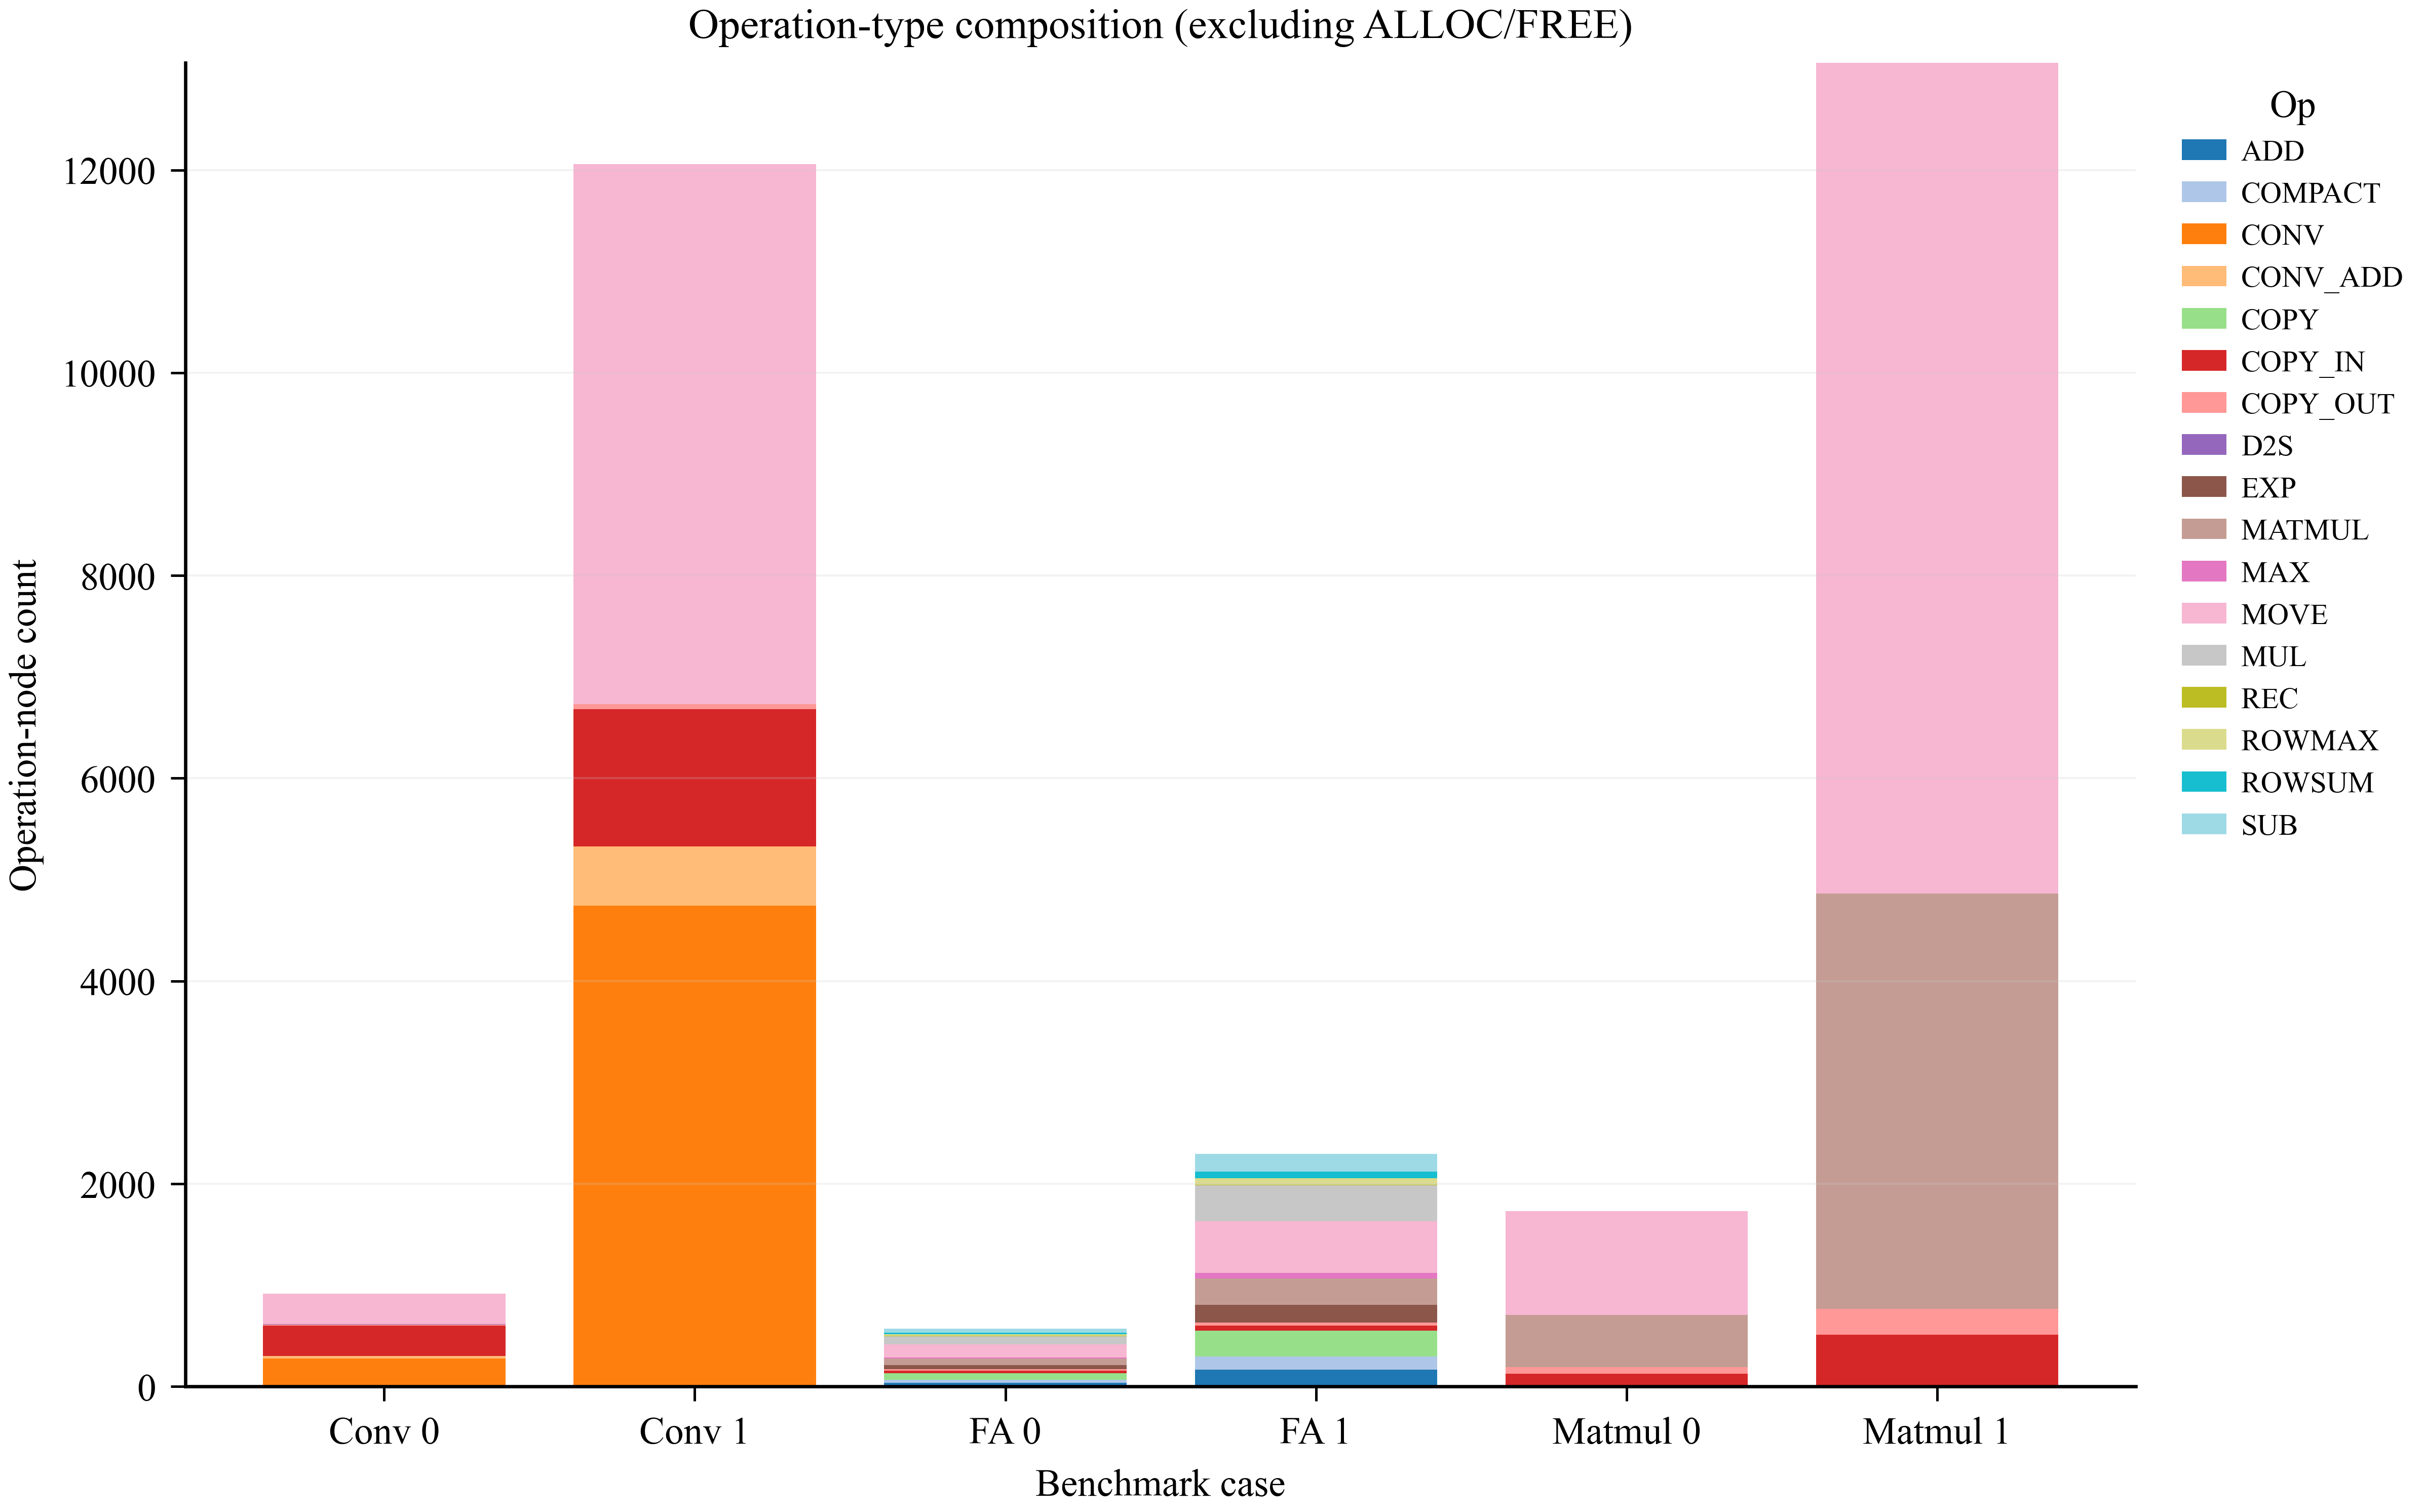

In [6]:
op_pivot = (
    order_cases(read("inv_op_distribution.csv"))
    .pivot(index="case", columns="category", values="count")
    .reindex(CASE_ORDER)
    .fillna(0)
)
fig, ax = make_figure("notebook")
op_pivot.plot(kind="bar", stacked=True, ax=ax, width=0.78, colormap="tab20", legend=False)
ax.set_xticklabels([case_label(c) for c in op_pivot.index], rotation=0)
style_bar_axes(ax, ylabel="Operation-node count")
ax.set_title("Operation-type composition (excluding ALLOC/FREE)")
ax.legend(title="Op", ncol=1, bbox_to_anchor=(1.01, 1.0), loc="upper left", fontsize=7)
save_fig(fig, "op_type_distribution.png")
fig

Conv and Matmul are dominated by their core compute operator plus data
movement; FlashAttention spreads across more operator types, so its schedule
must interleave several compute stages rather than one dominant kind.

Saved: output/01_data_and_problem/pipe_distribution.png


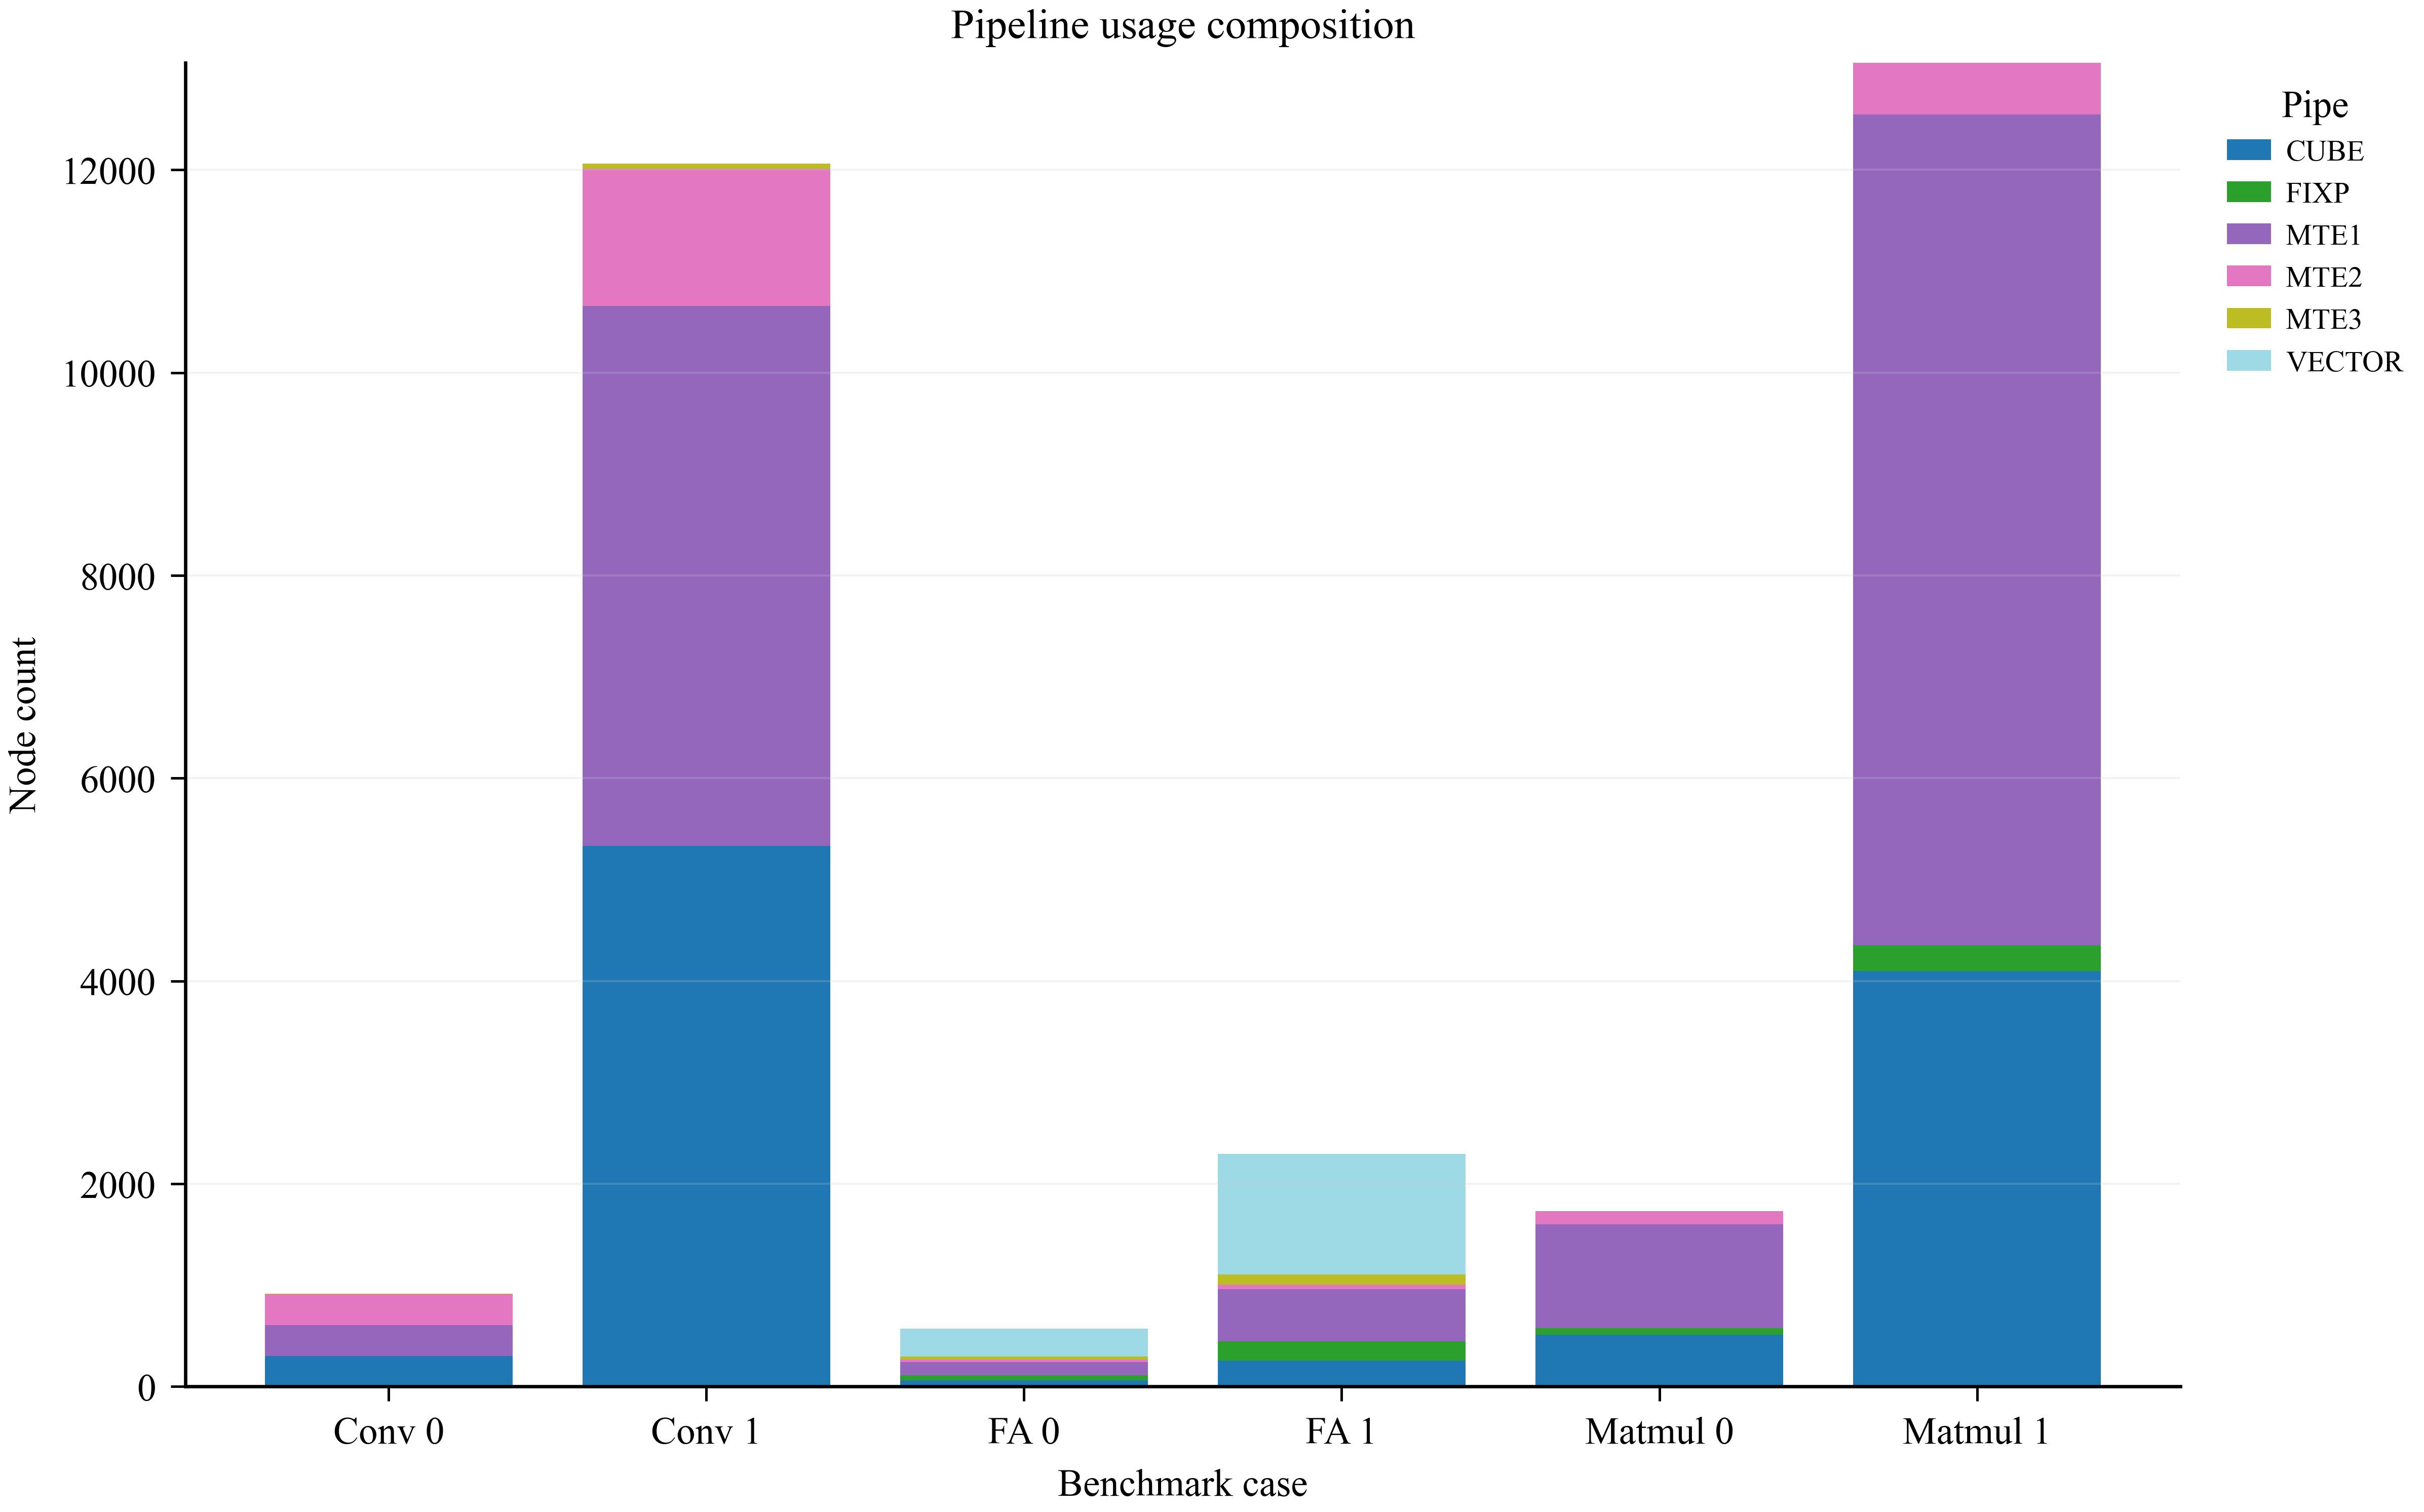

In [7]:
pipe_pivot = (
    order_cases(read("inv_pipe_distribution.csv"))
    .pivot(index="case", columns="category", values="count")
    .reindex(CASE_ORDER)
    .fillna(0)
)
fig, ax = make_figure("notebook")
pipe_pivot.plot(kind="bar", stacked=True, ax=ax, width=0.78, colormap="tab20", legend=False)
ax.set_xticklabels([case_label(c) for c in pipe_pivot.index], rotation=0)
style_bar_axes(ax, ylabel="Node count")
ax.set_title("Pipeline usage composition")
ax.legend(title="Pipe", ncol=1, bbox_to_anchor=(1.01, 1.0), loc="upper left", fontsize=7)
save_fig(fig, "pipe_distribution.png")
fig

Conv/Matmul concentrate on data movement and the CUBE pipeline, whereas
FlashAttention also exercises VECTOR/FIXP pipelines. The more pipelines a
kernel spans, the more cross-pipeline parallelism P3's time objective can —
and must — exploit.

### A.6 Cache-layer allocation

How statically allocated buffer bytes distribute across memory types.

In [8]:
cache = order_cases(read("inv_cache_layer.csv"))
display(cache)

,case,mem_type,buffer_count,total_size,max_buffer_size
0,Conv_Case0,L0B,300,17776,96
1,Conv_Case0,L1,531,133031,1536
2,Conv_Case1,L0B,5330,187056,96
3,Conv_Case1,L1,6683,383112,256
4,FlashAttention_Case0,L0A,64,8192,128
5,FlashAttention_Case0,L0B,64,8192,128
6,FlashAttention_Case0,L0C,48,12288,256
7,FlashAttention_Case0,L1,40,10240,256
8,FlashAttention_Case0,UB,356,25352,128
9,FlashAttention_Case1,UB,1512,105616,128


Saved: output/01_data_and_problem/cache_layer_distribution.png


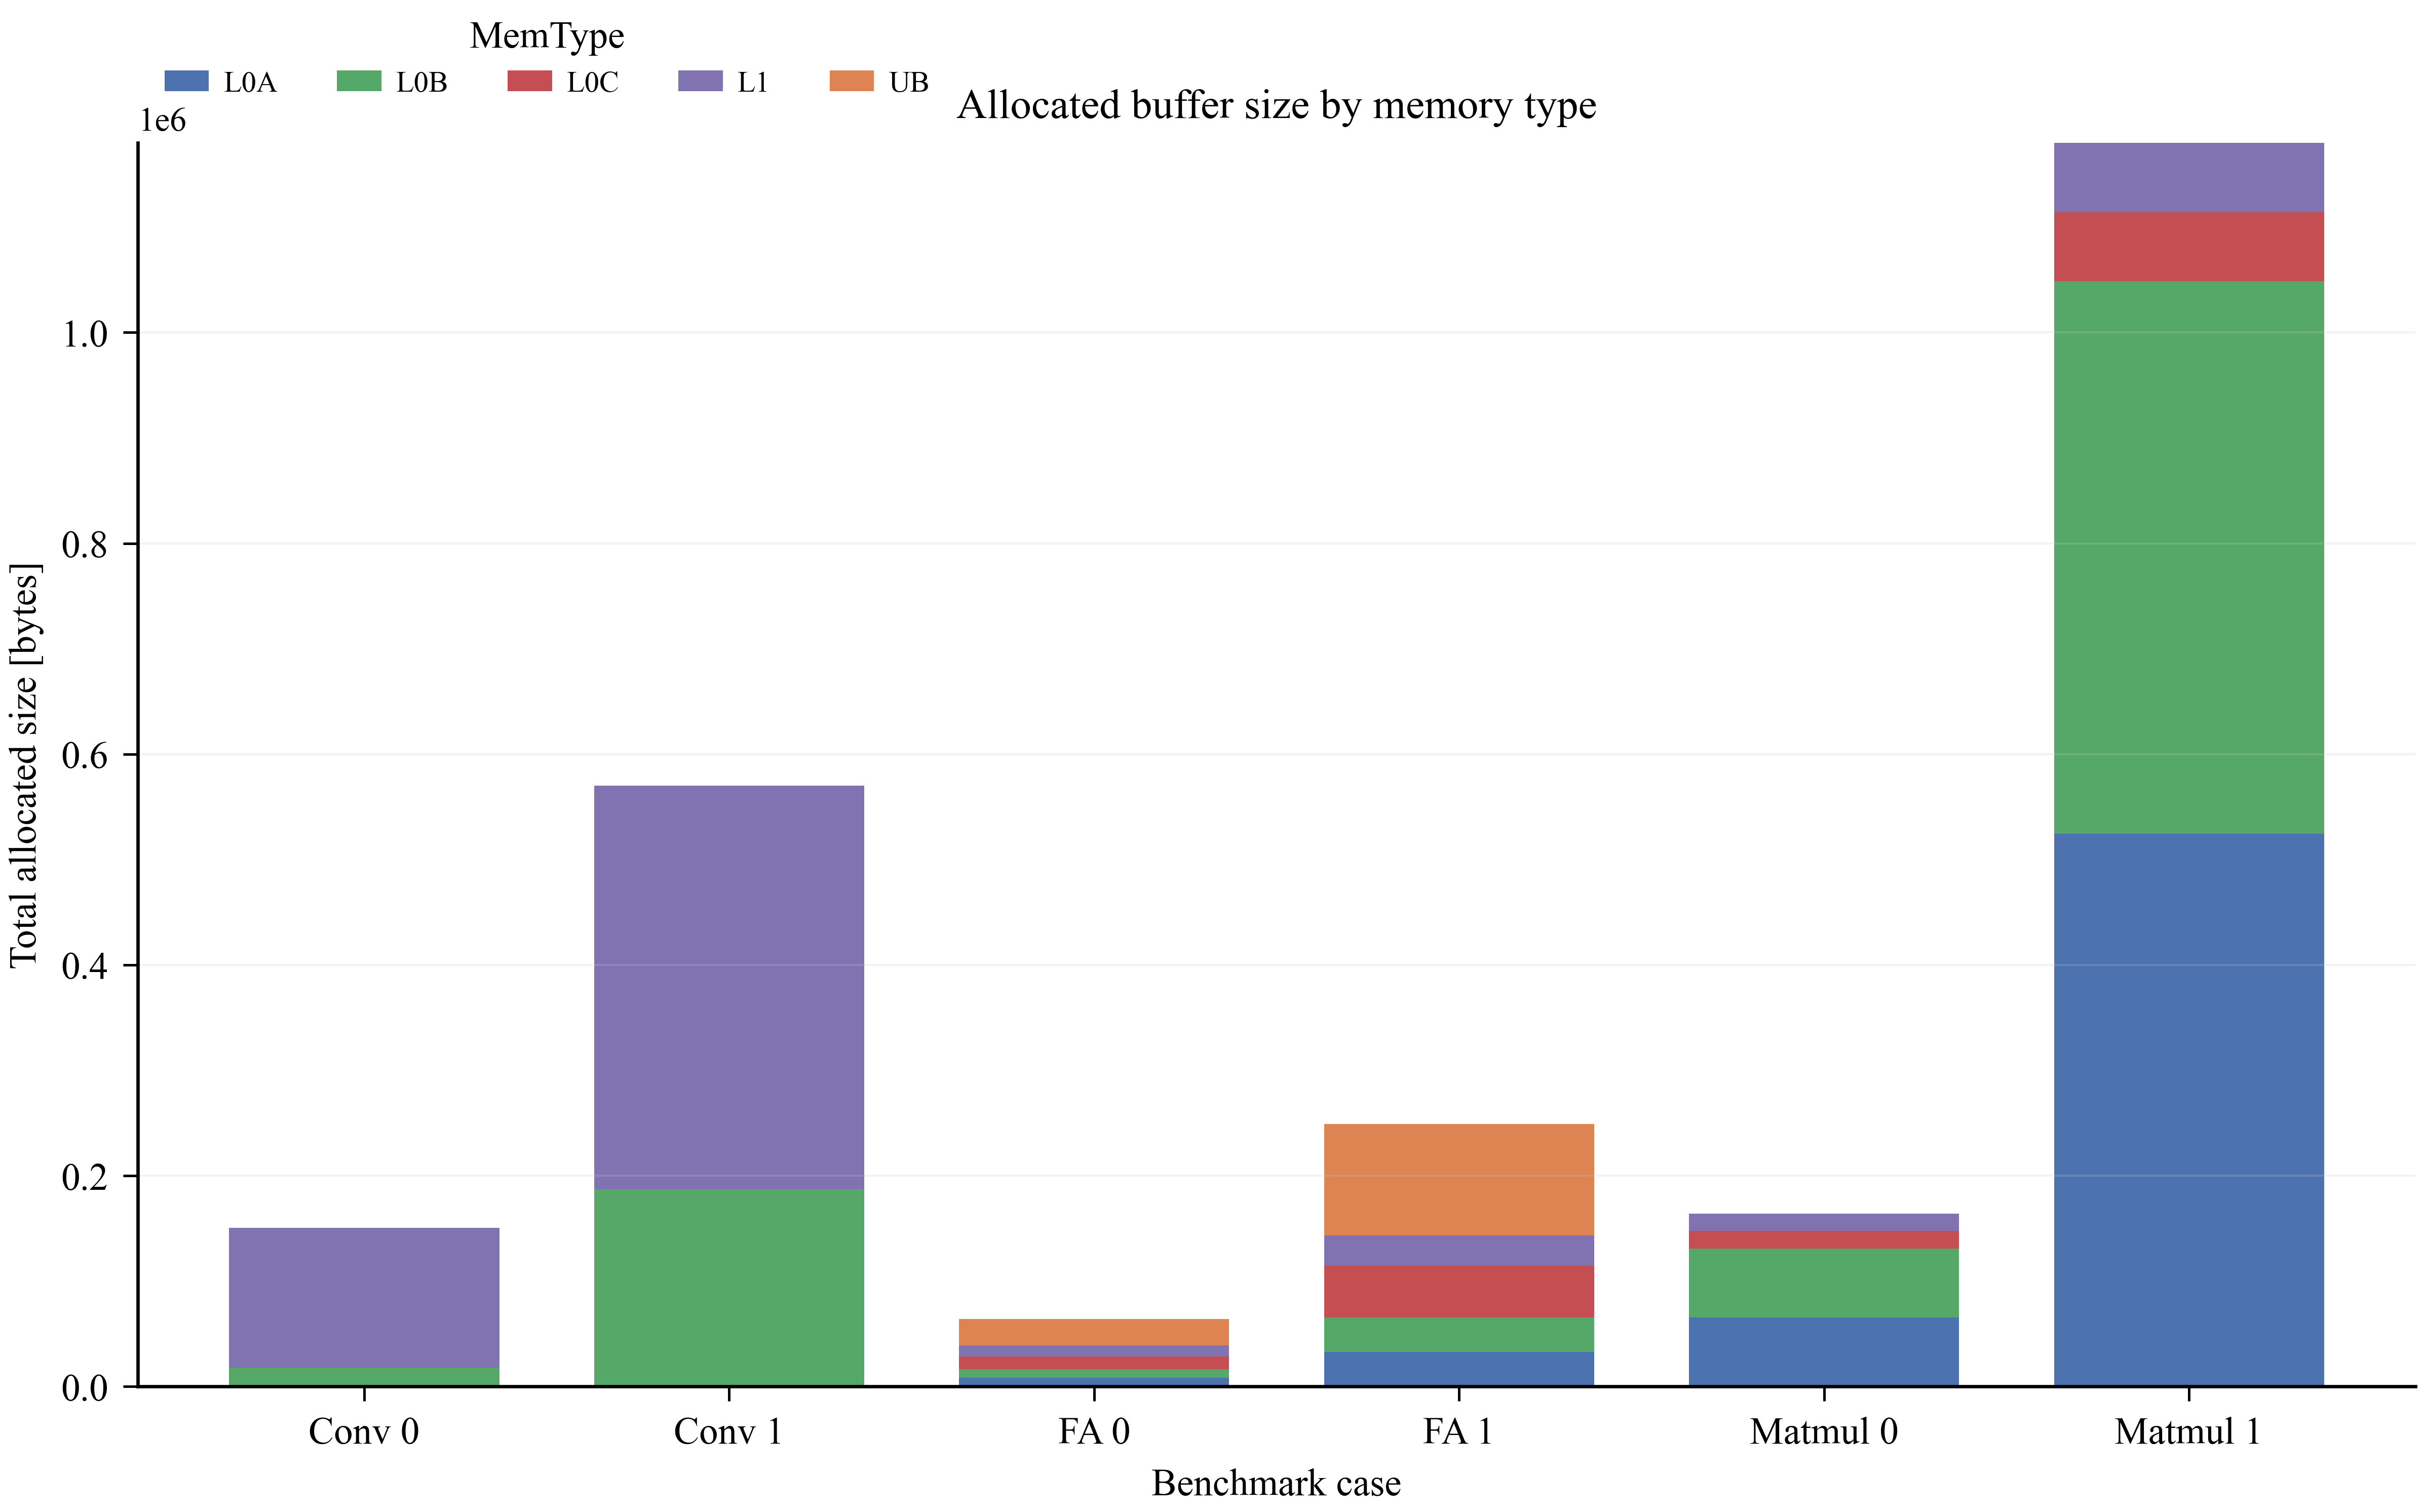

In [9]:
cache_pivot = (
    cache.pivot(index="case", columns="mem_type", values="total_size")
    .reindex(CASE_ORDER)
    .fillna(0)
)
fig, ax = make_figure("notebook")
cache_pivot.plot(
    kind="bar", stacked=True, ax=ax, width=0.74,
    color=METHOD_COLOR_LIST[: cache_pivot.shape[1]], legend=False,
)
ax.set_xticklabels([case_label(c) for c in cache_pivot.index], rotation=0)
style_bar_axes(ax, ylabel="Total allocated size [bytes]")
ax.set_title("Allocated buffer size by memory type")
ax.legend(title="MemType", ncol=cache_pivot.shape[1], loc="upper left", bbox_to_anchor=(0.0, 1.12), fontsize=7)
save_fig(fig, "cache_layer_distribution.png")
fig

Static L1 demand dominates for the large instances and is the principal
source of on-chip pressure. FlashAttention additionally leans on UB, so UB
capacity — not just L1 — can become the binding constraint, a point the P1
analysis below makes quantitative.

### A.7 Structural validation

Three checks that the graphs are well-formed enough to schedule: edge
quality, buffer lifecycle closure, and DAG legality.

In [10]:
display(read("inv_edge_validation.csv"))

,case,self_loops,missing_node_refs,isolated_nodes
0,Conv_Case0,0,0,0
1,Conv_Case1,0,0,0
2,FlashAttention_Case0,0,0,0
3,FlashAttention_Case1,0,0,0
4,Matmul_Case0,0,0,0
5,Matmul_Case1,0,0,0


No self-loops, no edges referencing missing nodes, and no isolated nodes —
the edge set is clean for topological analysis.

In [11]:
display(read("inv_buffer_consistency.csv"))

,case,buffers,bad_alloc_counts,bad_free_counts,op_refs_without_alloc,passed
0,Conv_Case0,831,0,0,0,True
1,Conv_Case1,12013,0,0,0,True
2,FlashAttention_Case0,572,0,0,0,True
3,FlashAttention_Case1,2328,0,0,0,True
4,Matmul_Case0,1216,0,0,0,True
5,Matmul_Case1,8960,0,0,0,True


Every `BufId` has exactly one `ALLOC` and one `FREE`, and every operation's
buffer reference resolves to an allocation. Buffer lifecycles are closed, so
residency and physical-address reuse can be computed over `ALLOC..FREE`
intervals.

In [12]:
display(read("inv_dag_topology.csv"))

,case,is_dag,weak_components,root_nodes,roots_all_alloc,leaf_nodes,leaves_all_free,topological_generations
0,Conv_Case0,True,1,831,True,831,True,60
1,Conv_Case1,True,1,12013,True,12013,True,148
2,FlashAttention_Case0,True,1,572,True,572,True,22
3,FlashAttention_Case1,True,1,2328,True,2328,True,30
4,Matmul_Case0,True,1,1216,True,1216,True,13
5,Matmul_Case1,True,1,8960,True,8960,True,21


Each instance is a valid DAG whose roots are all `ALLOC` and whose leaves are
all `FREE`; the topological-generation count reflects each kernel's dependency
depth.

In [13]:
display(read("inv_integrity_summary.csv"))

,case,passed,issues
0,Conv_Case0,True,NaN
1,Conv_Case1,True,NaN
2,FlashAttention_Case0,True,NaN
3,FlashAttention_Case1,True,NaN
4,Matmul_Case0,True,NaN
5,Matmul_Case1,True,NaN


The roll-up combines node contiguity, buffer lifecycle, edge references,
acyclicity, root/leaf legality, and field completeness into one verdict: all
six instances pass. The data is trustworthy; the rest of the notebook frames
the optimization problem on top of it.

## Part B — Problem framing

### B.1 The three sub-problems

P1, P2, and P3 form a progression over the same schedule.

In [14]:
display(read("prob_overview.csv").style.set_properties(**{"text-align": "left"}))

,problem,optimization_target,output_files,metric_formula,direction
0,Problem 1,Minimize peak resident cache demand for a valid topological schedule,_schedule.txt,max prefix V_stay over ALLOC/FREE size deltas,minimize maxV_stay
1,Problem 2,Assign cache offsets and spills under capacity constraints,"_schedule.txt, _memory.txt, _spill.txt",sum spill cost: Size or 2*Size depending on COPY_IN usage,minimize extra DDR traffic
2,Problem 3,Reduce pipelined execution time with spill and reuse dependencies,"_schedule.txt, _memory.txt, _spill.txt","T = max E(v) under DAG, same-pipe, spill, and reuse constraints",minimize total time


**P1** optimizes only the peak resident cache demand of a legal topological
order. **P2** adds physical address assignment and spill/reuse on top of that
order. **P3** further folds same-pipeline serialization, DAG dependencies, and
spill/reuse dependencies into a total-time objective. Each problem strictly
contains the previous one's constraints.

### B.2 Hardware capacities and P1 pressure

The on-chip capacities the schedule must respect. *This is the capacity table
the supplement reports.*

In [15]:
display(read("prob_capacities.csv"))

,cache,capacity
0,L1,4096
1,UB,1024
2,L0A,256
3,L0B,256
4,L0C,512


L1 and UB are the capacity-binding levels for peak residency; L0A/L0B/L0C are
small matrix-compute buffers. The chart below expresses each instance's
baseline P1 peak as a multiple of the relevant capacity, so a bar above 1.0
means a legal order alone overflows that cache.

,case,max_L1,max_UB,L1_ratio,UB_ratio
0,Conv_Case0,7488,0,1.828125,0.000000
1,Conv_Case1,14040,0,3.427734,0.000000
2,FlashAttention_Case0,3328,1428,0.812500,1.394531
3,FlashAttention_Case1,5376,2468,1.312500,2.410156
4,Matmul_Case0,9216,0,2.250000,0.000000
5,Matmul_Case1,34816,0,8.500000,0.000000


Saved: output/01_data_and_problem/p1_peak_vs_capacity.png


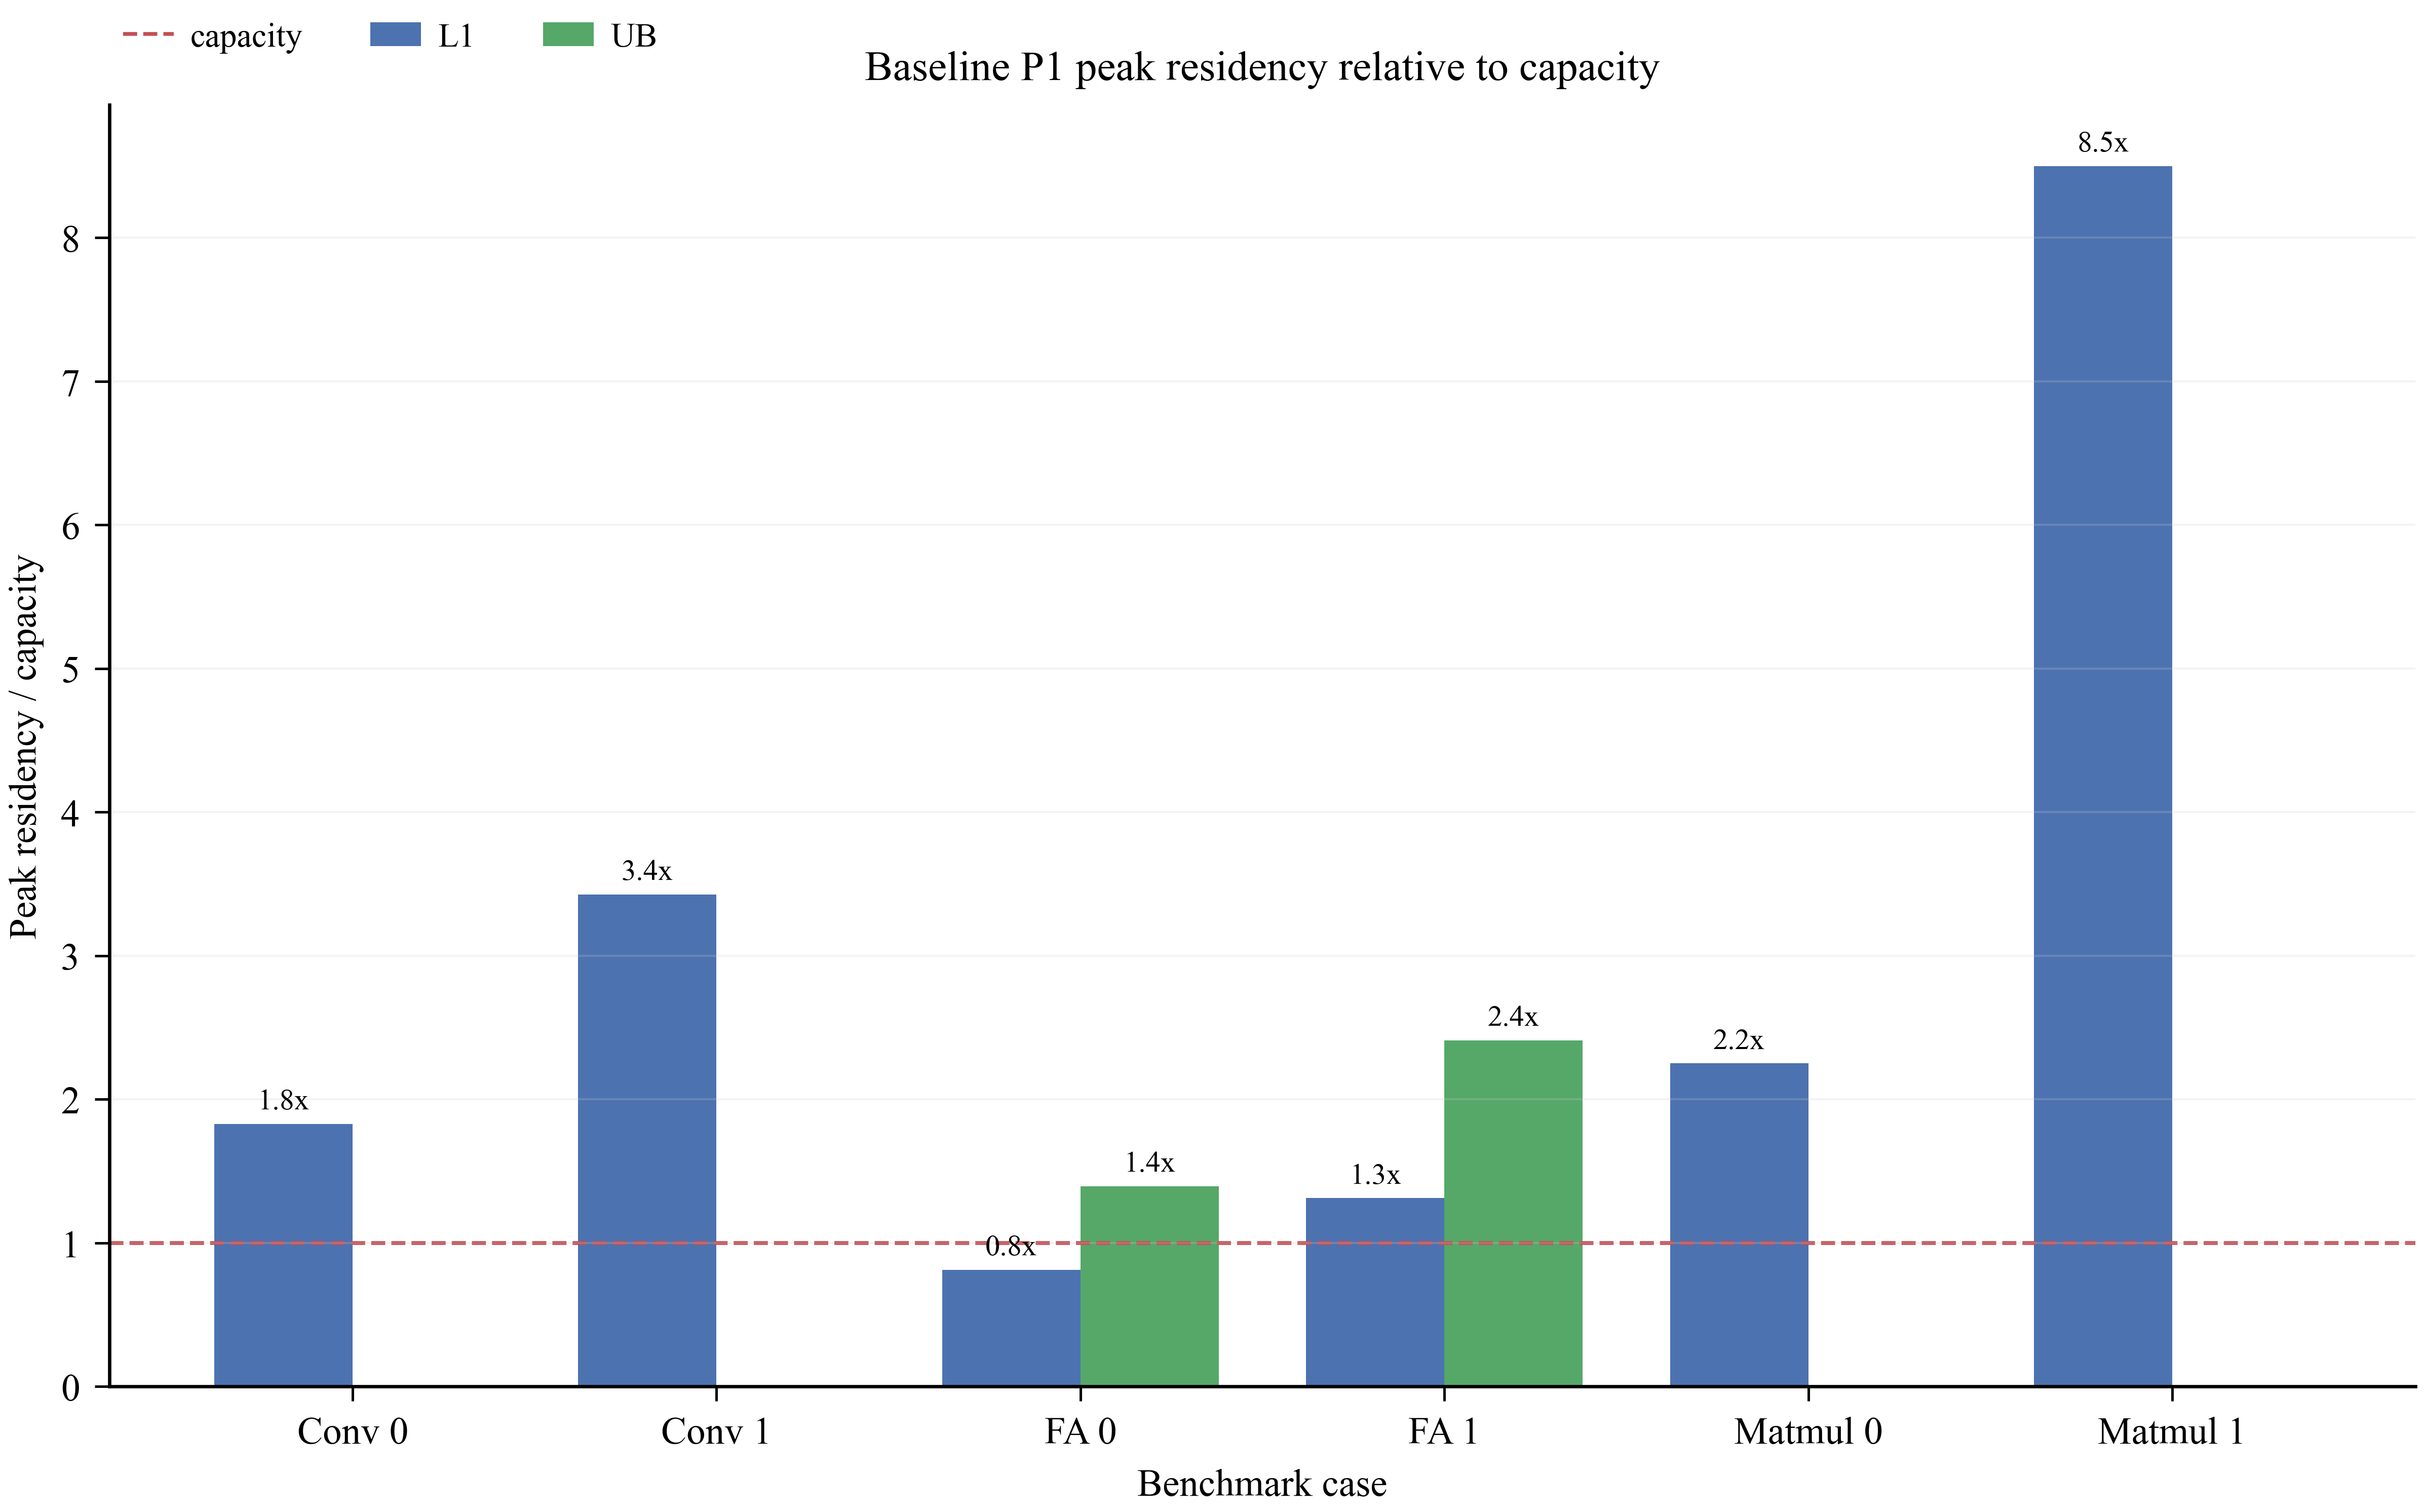

In [16]:
p1 = order_cases(read("prob_p1.csv"))
display(p1)

x = np.arange(len(p1))
w = 0.38
off = grouped_offsets(2, w)
fig, ax = make_figure("notebook")
b1 = ax.bar(x + off[0], p1["L1_ratio"], w, color=METHOD_PALETTE["primary"], label="L1")
b2 = ax.bar(x + off[1], p1["UB_ratio"], w, color=METHOD_PALETTE["secondary"], label="UB")
add_reference_line(ax, 1.0, "capacity", color=METHOD_PALETTE["accent_1"])
annotate_bars(ax, b1, formatter=lambda v: f"{v:.1f}x", rotation=0, fontsize=7)
annotate_bars(ax, b2, formatter=lambda v: f"{v:.1f}x", rotation=0, fontsize=7, min_value=0.01)
ax.set_xticks(x)
ax.set_xticklabels([case_label(c) for c in p1["case"]])
style_bar_axes(ax, ylabel="Peak residency / capacity")
ax.set_title("Baseline P1 peak residency relative to capacity")
place_bar_legend(ax, ncol=3)
save_fig(fig, "p1_peak_vs_capacity.png")
fig

L1 is over capacity for every Conv/Matmul instance and worst on Matmul_Case1
(8.5×). UB pressure is unique to FlashAttention (up to 2.4×), where L1 is
actually under capacity. So spill/reuse cannot be an L1-only concern — UB is
the binding constraint on FlashAttention.

### B.3 Baseline metrics — full table

The reference point all later work is measured against.

In [17]:
bm = read("prob_baseline_metrics.csv")
bm["case"] = pd.Categorical(bm["case"], categories=CASE_ORDER, ordered=True)
display(bm.sort_values(["case", "problem"]).reset_index(drop=True))

,case,problem,max_L1,max_UB,spills,extra,time
0,Conv_Case0,1,7488,0,0,0,359570
1,Conv_Case0,2,7488,0,141,73500,535312
2,Conv_Case0,3,7488,0,141,73500,535312
3,Conv_Case1,1,14040,0,0,0,573395
4,Conv_Case1,2,14040,0,1828,73240,1150333
5,Conv_Case1,3,14040,0,1290,86690,1073322
6,FlashAttention_Case0,1,3328,1428,0,0,31429
7,FlashAttention_Case0,2,3328,1428,41,3692,53374
8,FlashAttention_Case0,3,3328,1428,24,4128,46761
9,FlashAttention_Case1,1,5376,2468,0,0,113445


These 18 rows (6 cases × 3 problems) carry the peak cache, spill count, extra
DDR traffic, and time that define the baseline. They are taken straight from
the same source as the paper's headline comparison (`e1_headline.csv`), so the
problem-framing numbers here cannot drift from the headline results.

### B.4 P2 — spill cost

How much traffic the baseline spends to fit the working set on-chip.

,case,spills,extra,op_nodes,spill_density
0,Conv_Case0,141,73500,918,0.153595
1,Conv_Case1,1828,73240,12060,0.151575
2,FlashAttention_Case0,41,3692,572,0.071678
3,FlashAttention_Case1,146,32840,2296,0.063589
4,Matmul_Case0,273,34944,1728,0.157986
5,Matmul_Case1,3600,460800,13056,0.275735


Saved: output/01_data_and_problem/p2_spill_cost.png


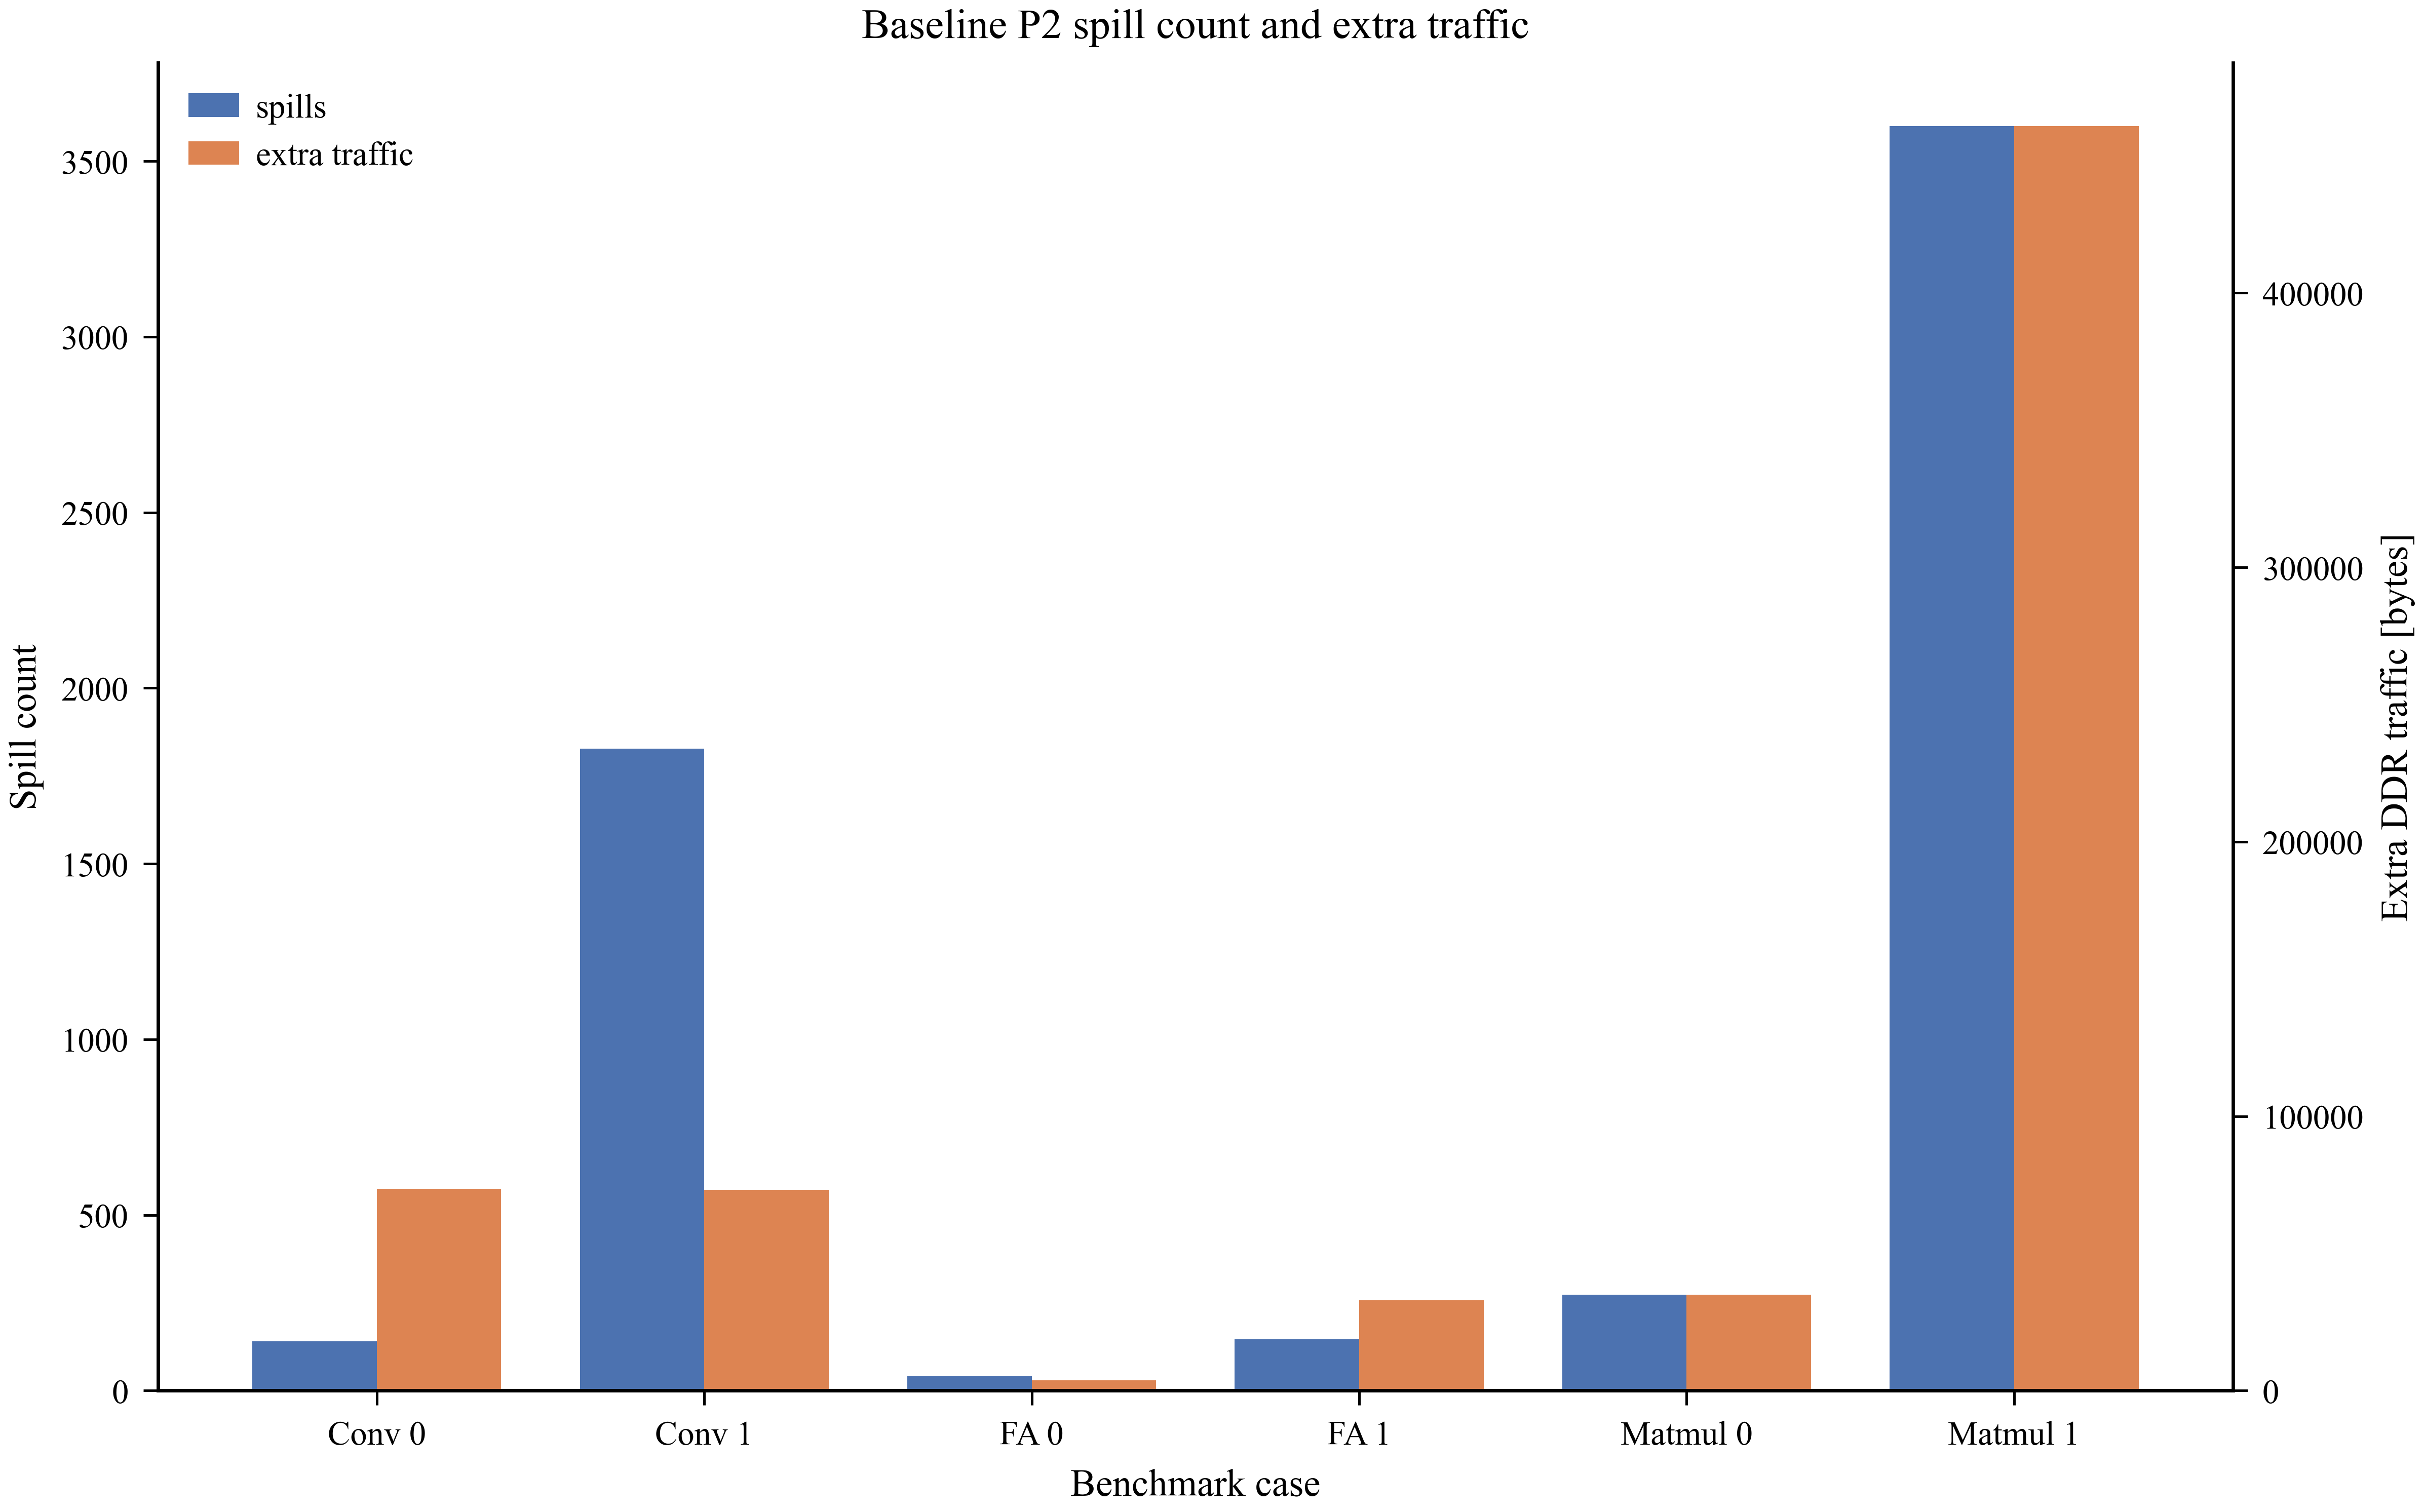

In [18]:
p2 = order_cases(read("prob_p2.csv"))
display(p2)

x = np.arange(len(p2))
w = 0.38
off = grouped_offsets(2, w)
fig, ax = make_figure("notebook")
ax2 = ax.twinx()
ax2.spines["right"].set_visible(True)
b1 = ax.bar(x + off[0], p2["spills"], w, color=METHOD_PALETTE["primary"], label="spills")
b2 = ax2.bar(x + off[1], p2["extra"], w, color=METHOD_PALETTE["accent_3"], label="extra traffic")
ax.set_xticks(x)
ax.set_xticklabels([case_label(c) for c in p2["case"]])
ax.set_xlabel("Benchmark case")
ax.set_ylabel("Spill count")
ax2.set_ylabel("Extra DDR traffic [bytes]")
ax.set_title("Baseline P2 spill count and extra traffic")
ax.legend([b1, b2], ["spills", "extra traffic"], loc="upper left", frameon=False, fontsize=8)
save_fig(fig, "p2_spill_cost.png")
fig

`spill_density` normalizes spills by operation count so difficulty is not
confounded by raw instance size. Matmul_Case1 is heaviest on both axes;
Conv_Case1 has many spills but less extra traffic, showing that buffer-size
structure — not just spill count — drives the actual data movement P2 pays for.

### B.5 P3 — execution time

How the time objective grows as the problem adds constraints.

,case,P1_time,P2_time,P3_time,P2_P1_ratio,P3_P1_ratio
0,Conv_Case0,359570,535312,535312,1.488756,1.488756
1,Conv_Case1,573395,1150333,1073322,2.006179,1.871872
2,FlashAttention_Case0,31429,53374,46761,1.698240,1.487830
3,FlashAttention_Case1,113445,193059,193059,1.701785,1.701785
4,Matmul_Case0,82773,194331,194331,2.347758,2.347758
5,Matmul_Case1,583525,1800218,1800218,3.085074,3.085074


Saved: output/01_data_and_problem/p3_time_comparison.png


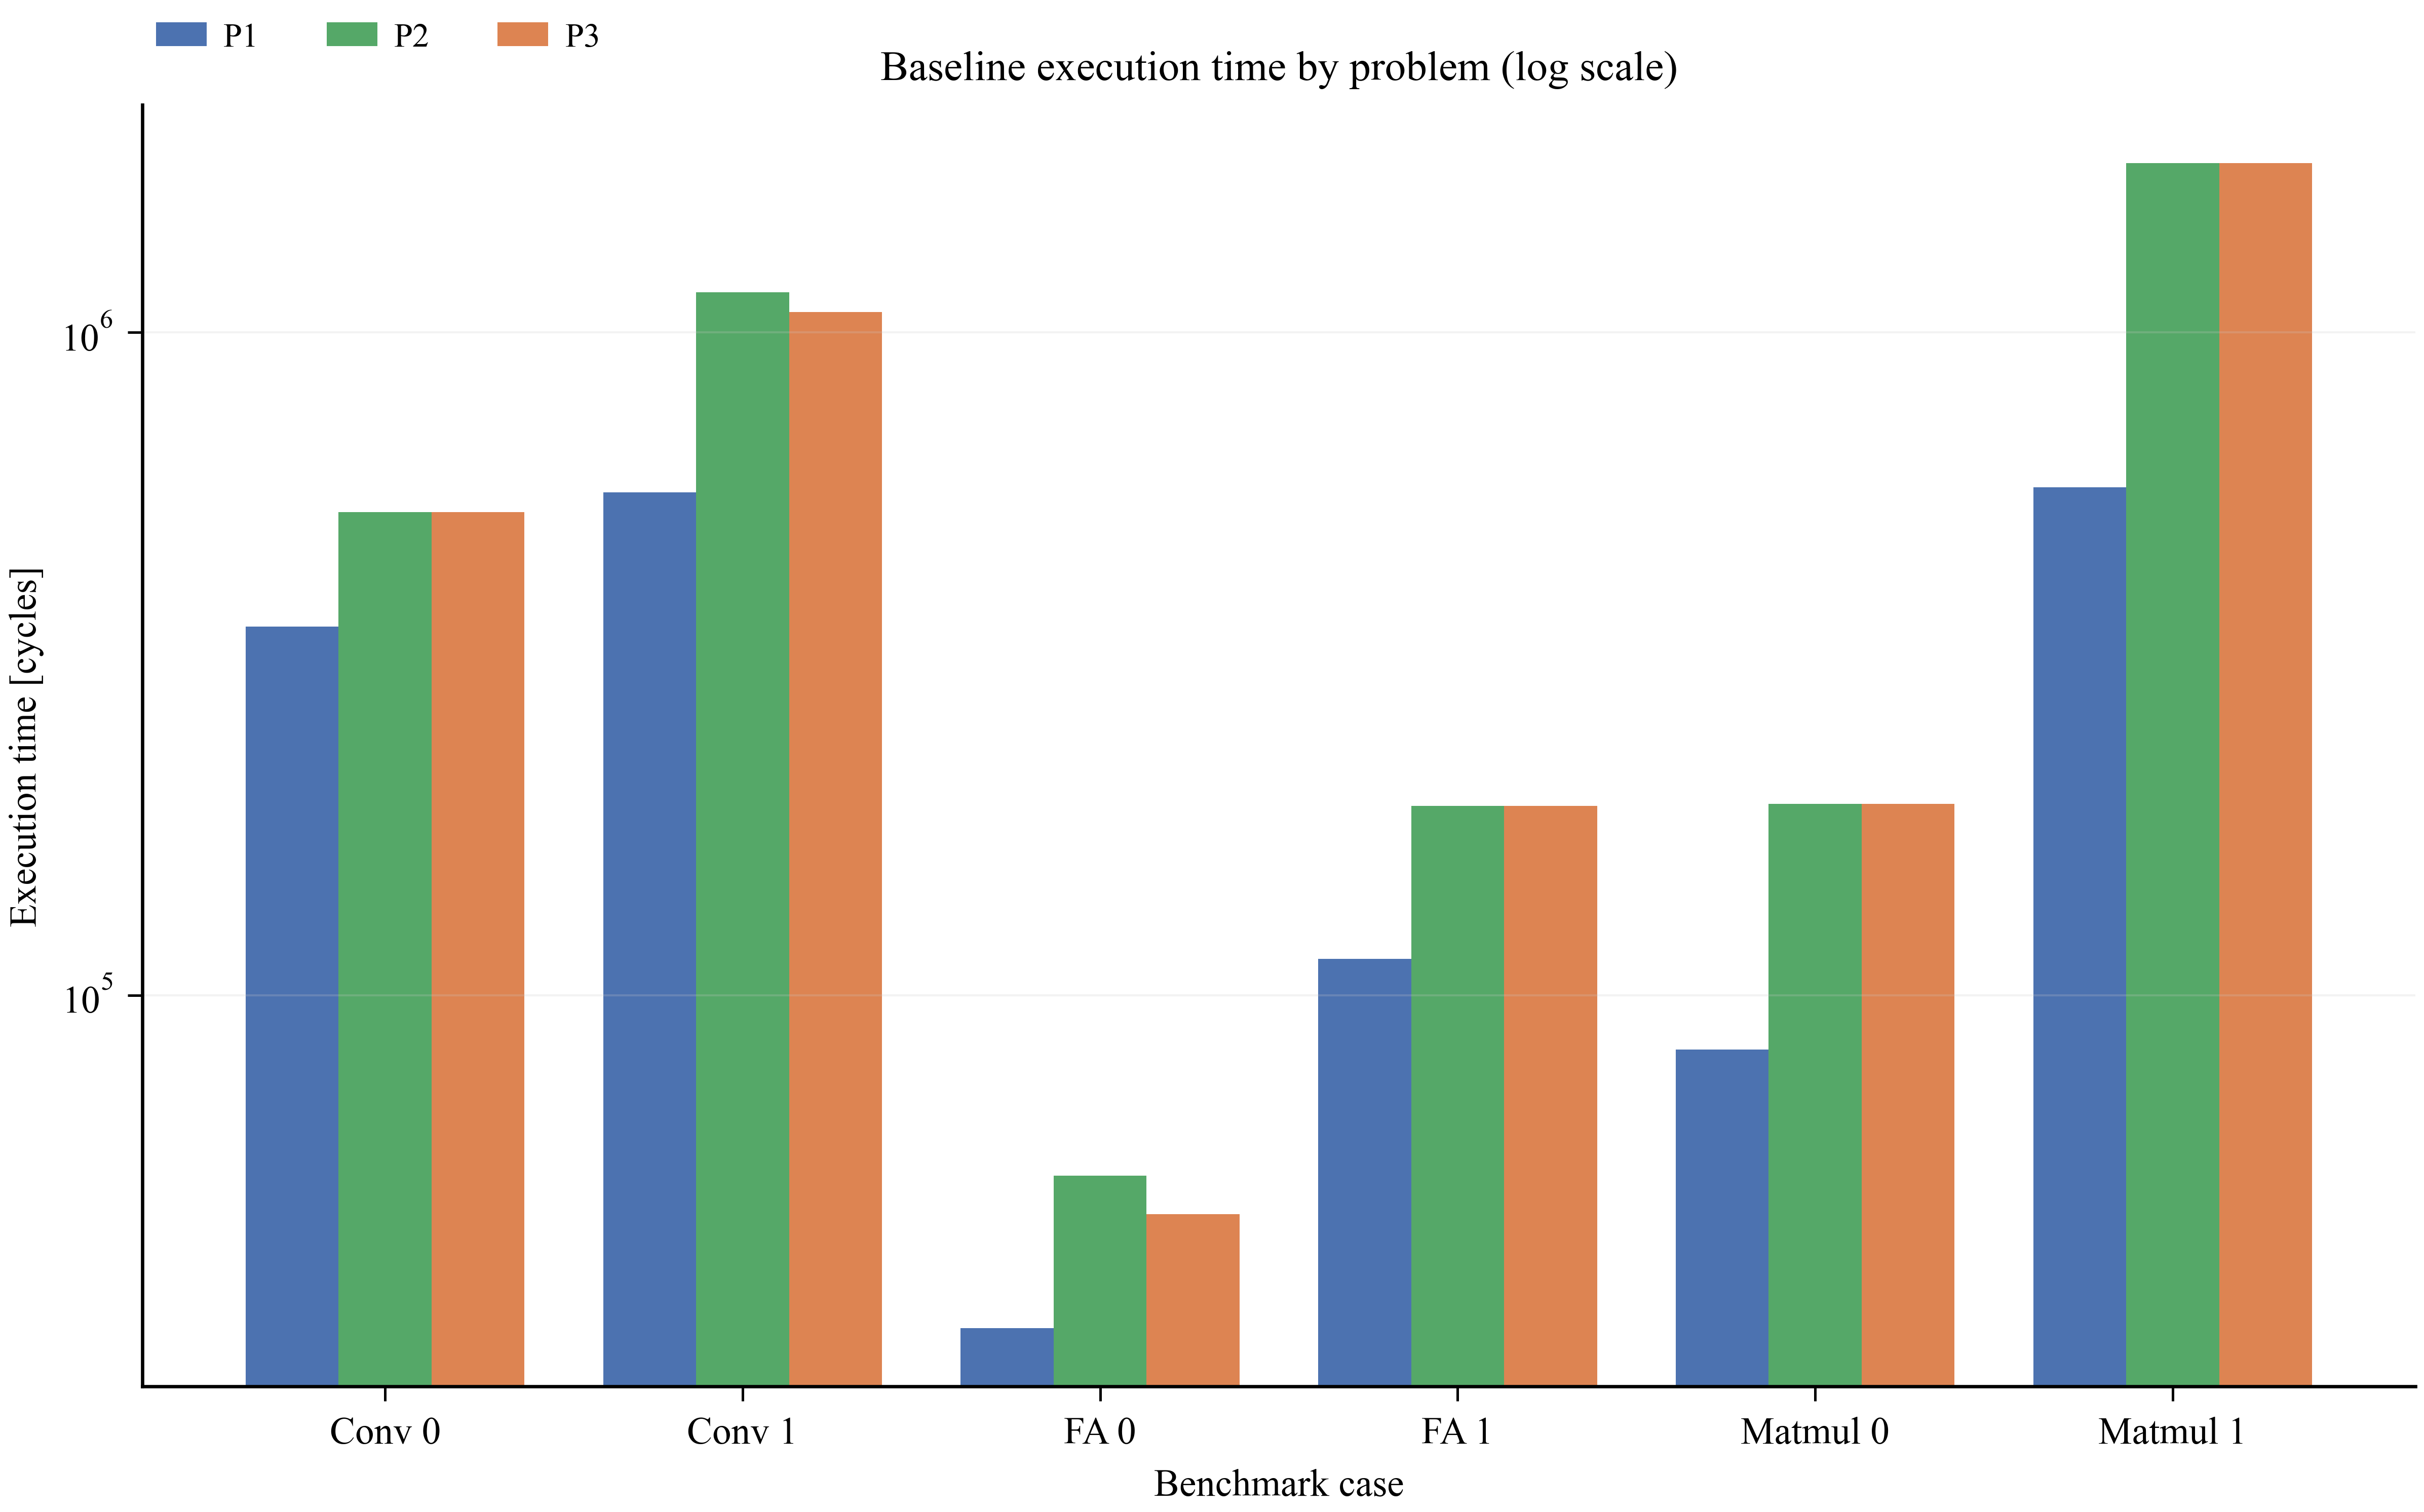

In [19]:
t = order_cases(read("prob_time.csv"))
display(t)

x = np.arange(len(t))
w = 0.26
off = grouped_offsets(3, w)
series = [
    ("P1_time", "P1", METHOD_PALETTE["primary"]),
    ("P2_time", "P2", METHOD_PALETTE["secondary"]),
    ("P3_time", "P3", METHOD_PALETTE["accent_3"]),
]
fig, ax = make_figure("notebook")
for i, (col, lab, color) in enumerate(series):
    ax.bar(x + off[i], t[col], w, color=color, label=lab)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([case_label(c) for c in t["case"]])
style_bar_axes(ax, ylabel="Execution time [cycles]")
ax.set_title("Baseline execution time by problem (log scale)")
place_bar_legend(ax, ncol=3)
save_fig(fig, "p3_time_comparison.png")
fig

P2 time rises noticeably over P1 (spills add traffic), while P3 often lands
close to P2 — the baseline has limited room to recover time through
cross-pipeline scheduling, which is precisely where a stronger P3 method has
to act.

### B.6 Cross-case difficulty

A normalized side-by-side of where each instance is hard.

,L1_over_capacity,UB_over_capacity,P2_spills,P2_extra,P3_time
case,,,,,
Conv_Case0,0.215074,0.000000,0.039167,0.159505,0.297360
Conv_Case1,0.403263,0.000000,0.507778,0.158941,0.596218
FlashAttention_Case0,0.095588,0.578606,0.011389,0.008012,0.025975
FlashAttention_Case1,0.154412,1.000000,0.040556,0.071267,0.107242
Matmul_Case0,0.264706,0.000000,0.075833,0.075833,0.107949
Matmul_Case1,1.000000,0.000000,1.000000,1.000000,1.000000


Saved: output/01_data_and_problem/difficulty_heatmap.png


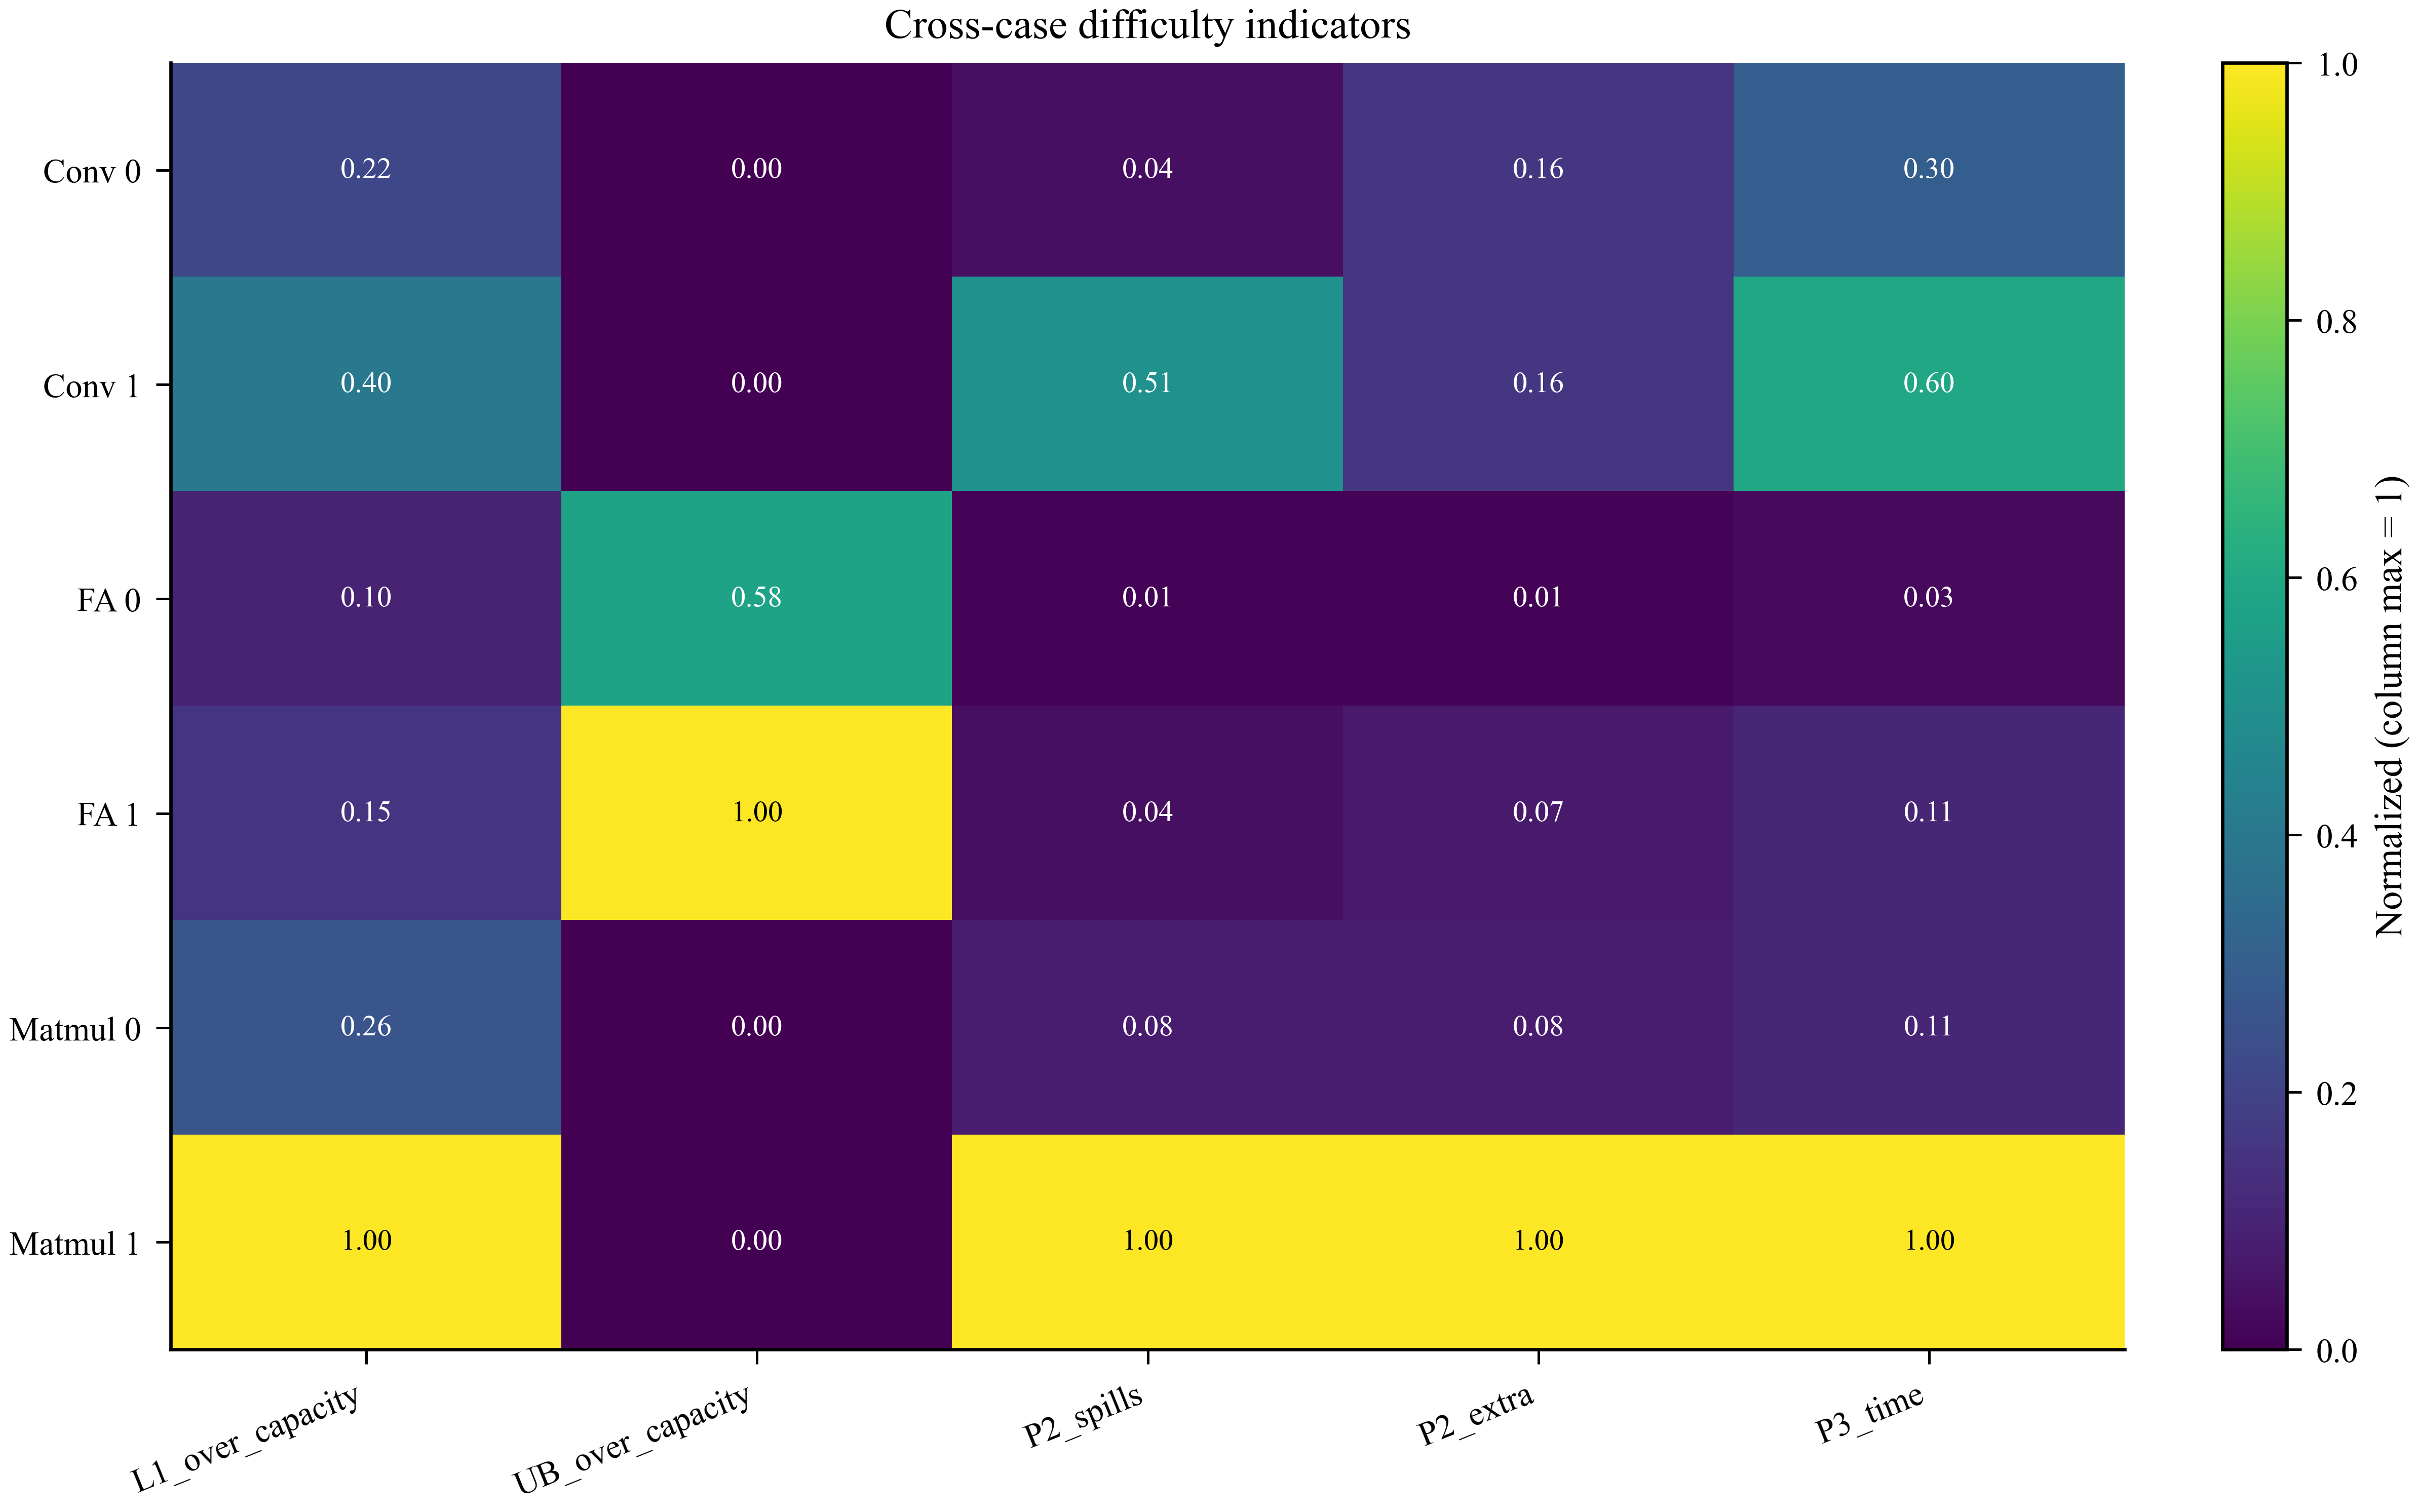

In [20]:
d = order_cases(read("prob_difficulty.csv")).set_index("case").reindex(CASE_ORDER)
display(d)

fig, ax = make_figure("notebook")
im = ax.imshow(d.values, cmap=COLORMAPS["coverage"], aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(d.columns)))
ax.set_xticklabels(d.columns, rotation=22, ha="right")
ax.set_yticks(range(len(d.index)))
ax.set_yticklabels([case_label(c) for c in d.index])
for i in range(d.shape[0]):
    for j in range(d.shape[1]):
        v = d.iat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if v < 0.6 else "black", fontsize=7)
fig.colorbar(im, ax=ax, label="Normalized (column max = 1)")
ax.set_title("Cross-case difficulty indicators")
save_fig(fig, "difficulty_heatmap.png")
fig

Each column is normalized to its own maximum. Matmul_Case1 saturates several
dimensions and is the hardest instance overall; FlashAttention's difficulty is
concentrated in UB pressure; Conv sits in between. This is the difficulty
landscape the method is evaluated against.

## Part C — A real schedule, walked

> **Explanatory figure (notebook-only) — not a paper figure.**

To make the problem concrete we walk one real instance (Conv_Case0) under the
promoted `id_raw` order: (a) how on-chip *demand* evolves across the whole
schedule, and (b) the DAG structure inside the highest-pressure window.

Saved: output/01_data_and_problem/x1_dag_walk.png


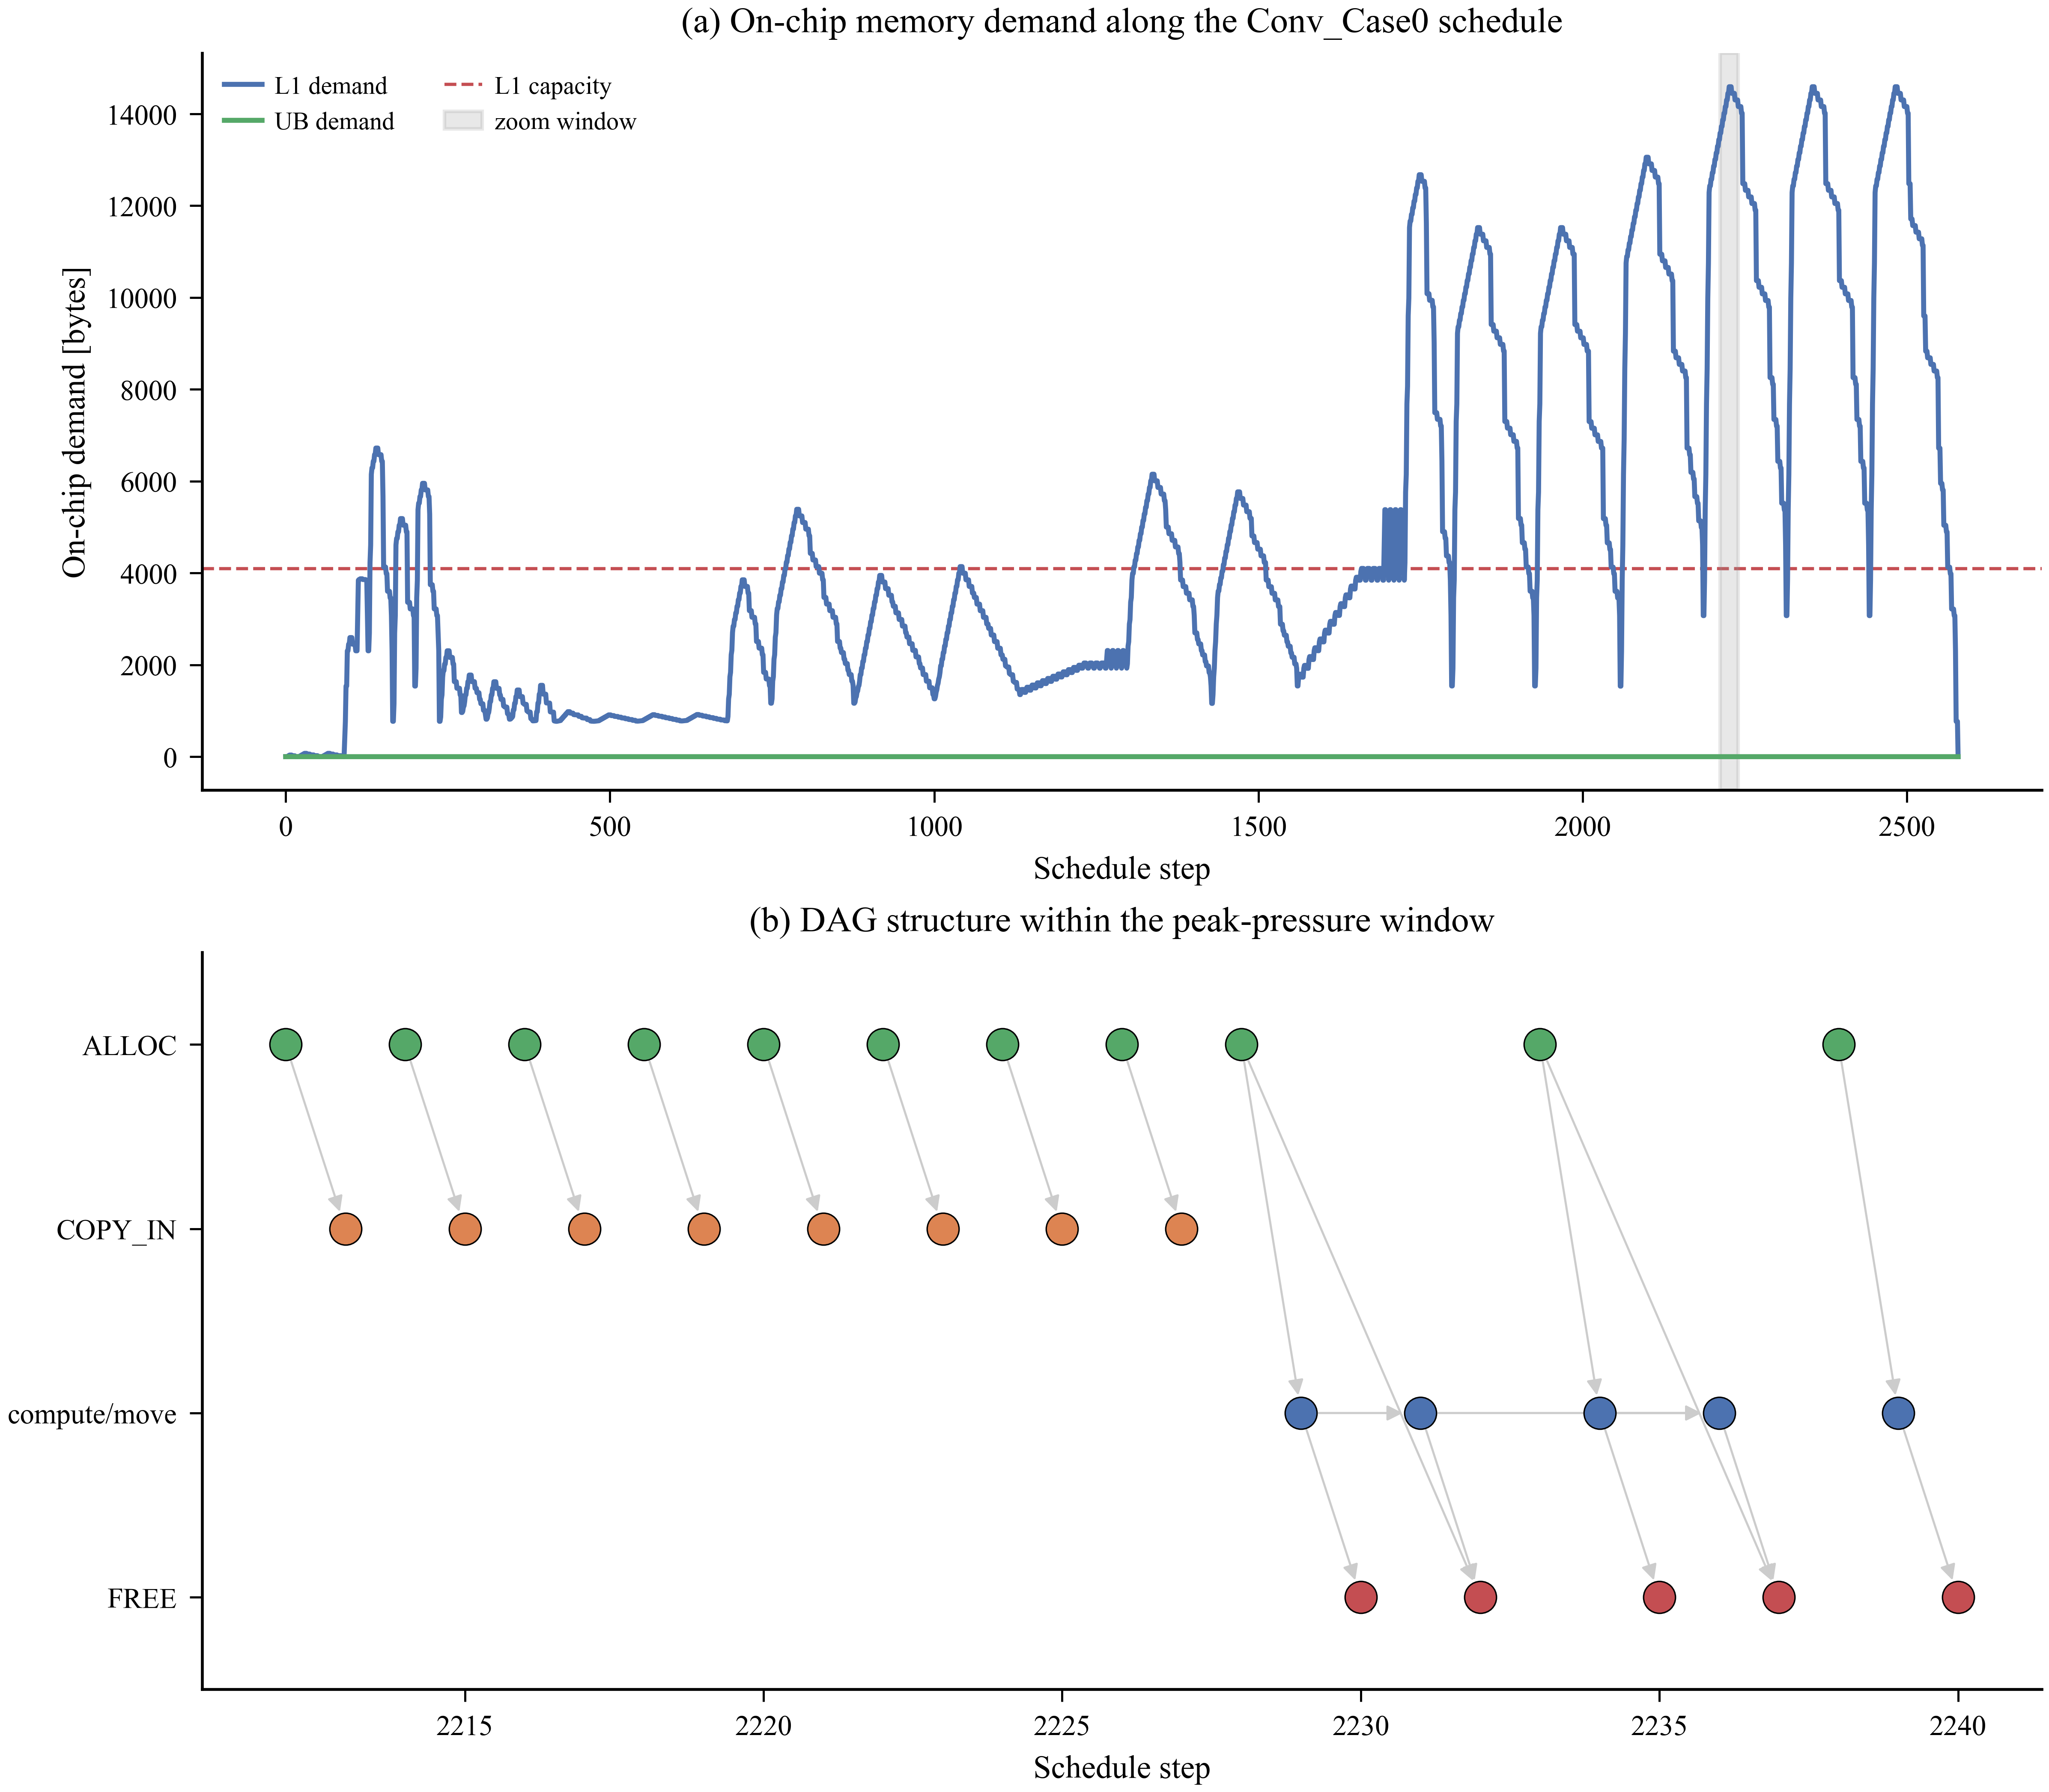

In [21]:
occ = read("x1_dag_occupancy.csv")
nodes = read("x1_dag_nodes.csv")
edges = read("x1_dag_edges.csv")
caps = read("prob_capacities.csv").set_index("cache")["capacity"]

peak_pos = int(occ.loc[occ["L1"].idxmax(), "pos"])
HALF = 14
lo, hi = peak_pos - HALF, peak_pos + HALF

fig, (ax_top, ax_bot) = make_figure("notebook", nrows=2)

# (a) demand curve over the whole schedule
ax_top.plot(occ["pos"], occ["L1"], color=METHOD_PALETTE["primary"], label="L1 demand")
ax_top.plot(occ["pos"], occ["UB"], color=METHOD_PALETTE["secondary"], label="UB demand")
add_reference_line(ax_top, caps["L1"], "L1 capacity", color=METHOD_PALETTE["accent_1"])
ax_top.axvspan(lo, hi, color="#999999", alpha=0.22, label="zoom window")
ax_top.set_xlabel("Schedule step")
ax_top.set_ylabel("On-chip demand [bytes]")
ax_top.set_title("(a) On-chip memory demand along the Conv_Case0 schedule")
ax_top.legend(ncol=2, fontsize=7, loc="upper left")

# (b) swimlane of the high-pressure window
LANES = {"FREE": 0, "compute/move": 1, "COPY_IN": 2, "ALLOC": 3}
COLOR = {
    "ALLOC": METHOD_PALETTE["secondary"],
    "FREE": METHOD_PALETTE["accent_1"],
    "COPY_IN": METHOD_PALETTE["accent_3"],
}


def lane(op):
    return LANES.get(op, LANES["compute/move"])


def ncolor(op):
    return COLOR.get(op, METHOD_PALETTE["primary"])


win = nodes[(nodes["sched_pos"] >= lo) & (nodes["sched_pos"] <= hi)].copy()
xpos = dict(zip(win["id"], win["sched_pos"]))
ypos = {nid: lane(op) for nid, op in zip(win["id"], win["op"])}
win_ids = set(win["id"])
for s, dst in zip(edges["src"], edges["dst"]):
    if s in win_ids and dst in win_ids:
        ax_bot.annotate(
            "", xy=(xpos[dst], ypos[dst]), xytext=(xpos[s], ypos[s]),
            arrowprops=dict(arrowstyle="-|>", color="#cccccc", lw=0.6, shrinkA=5, shrinkB=5),
        )
for r in win.itertuples():
    ax_bot.scatter(r.sched_pos, lane(r.op), s=80, color=ncolor(r.op),
                   edgecolor="black", linewidth=0.4, zorder=3)
ax_bot.set_yticks(list(LANES.values()))
ax_bot.set_yticklabels(list(LANES.keys()))
ax_bot.set_ylim(-0.5, 3.5)
ax_bot.set_xlabel("Schedule step")
ax_bot.set_title("(b) DAG structure within the peak-pressure window")
save_fig(fig, "x1_dag_walk.png")
fig

**Read.** Panel (a) shows L1 *demand* climbing far above the 4 KB L1 capacity
in a mid-schedule window — this is demand before any spilling, so it makes the
need for P2's spill/reuse machinery concrete: a legal order alone cannot keep
the working set on-chip. Panel (b) zooms into that window: `ALLOC` admits
buffers, `COPY_IN` brings in clean (already-backed) data, compute/move nodes
consume them, and `FREE` releases them. The band of simultaneously-live
`ALLOC`s is exactly what drives the peak — and what the paper's liveness
shaping reorders to flatten.